# **CIS 5450 Final Project - Taxi Demand Prediction**
*Darren Weng, Stanley Zhou, Yulia Zhu*

**Demo video link:** https://drive.google.com/file/d/1fsHRD_YtzMtfWt1H_NTpB76r0gzL9j_m/view?usp=sharing

# Part 1: Introduction

New York City’s yellow taxi system is a classic example of high-frequency, high-dimensional demand data. For our final project, we aim to understand:

How do weather conditions, holidays, and major NYC events affect hourly taxi demand across key Manhattan and airport zones from 2019–2024?

To answer this question, we construct a panel dataset at hourly x zone resolution for five representative taxi zones:


* Times Sq/Theatre District (230) - tourism, entertainment, nightlife
* World Trade Center (261) - financial district & business travel
* East Village (79) - dense residential + restaurants/nightlife
* Upper East Side South (237) - high-income residential / retail
* JFK Airport (132) - major transportation hub

Conceptually, we view hourly taxi demand as a function of:

* Intrinsic factors - time of day, day of week, month/season, zone
* Exogenous factors - weather (temperature, precipitation, snowfall, wind humidity)
* Calendar factors - U.S./NY holidays and major NYC events (e.g., New Year’s Eve in Times Square, NYC Marathon)

By combining these data sources, we hope to:

1. Quantify how extreme weather (e.g., snowstorms, heat waves) shifts taxi demand across different types of zones (airport vs entertainment vs residential).
2. Measure the demand impact of holidays and major events, particularly in tourism-heavy areas like Times Square and the WTC area.
3. Build a foundation for forecasting models that can incorporate weather and calendar features to better predict short-horizon taxi demand

For reference, [here is the example final project notebook](https://colab.research.google.com/drive/1t4gniy-Px6vIyImnjSXj2XgPuF8qbQqn#scrollTo=CvF_Vwn6FK7e)

# Part 2: Data Loading & Preprocessing

For this part, we (1) import core libraries, (2) load preprocessed taxi and weather data from GitHub, (3) merge them at the hourly level, and (4) enrich the dataset with holiday and major event indicators.

In [ ]:
# Core data / dates / holidays
import pandas as pd
import numpy as np
import holidays

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised learning (KMeans for demand tiers)
from sklearn.cluster import KMeans

# Preprocessing / scaling
from sklearn.preprocessing import StandardScaler

# Supervised models (regression + classification)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from scipy.stats import randint
from xgboost import XGBRegressor, XGBClassifier

# Model selection / CV / hyperparameter tuning
from sklearn.model_selection import (
    TimeSeriesSplit,
    HalvingRandomSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

# Set the option to display all columns
pd.set_option('display.max_columns', None)

## 2.1 Loading + Preprocessing Hourly Taxi + Weather Data

To ensure full reproducibility and avoid repeatedly hitting large external data sources (NYC TLC trip records and the Open-Meteo archive), we performed all heavy ingestion and aggregation in a [separate notebook](https://colab.research.google.com/drive/1laEpxqFOeQDgAJ6WXlc3YbgJsEodUQb5?authuser=2).
That notebook:

* Downloads monthly TLC Yellow Taxi trip records (parquet) from the [TLC CloudFront parquet archive](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) for 2019-2024.
* Filter to five representative NYC zones (Times Square, WTC, East Village, Upper East Side South, JFK).
* Floors pickup times to the nearest hour and aggregates to the `(zone_id, timestamp)` level.
* Fetch hourly NYC weather from the [Open-Meteo Historical Weather Archive API](https://open-meteo.com/en/docs/historical-forecast-api) in ~1-year chunks (2019–2024).

### 2.1.1 Loading Data From CSV into Dataframes

In [ ]:
# Load hourly taxi + weather data from GitHub (sourced in a different notebook that we can include)

taxi_url = "https://raw.githubusercontent.com/darrentweng/cis5450-final-project-data/main/nyc_taxi_hourly.csv"
weather_url = "https://raw.githubusercontent.com/darrentweng/cis5450-final-project-data/main/nyc_weather_hourly.csv"

In [ ]:
taxi_df = pd.read_csv(taxi_url, parse_dates=['timestamp'])
weather_df = pd.read_csv(weather_url, parse_dates=['timestamp'])

print("Taxi shape:", taxi_df.shape)
print("Weather shape:", weather_df.shape)

Taxi shape: (185462, 9)
Weather shape: (52608, 10)


In [ ]:
taxi_df.head()

,zone_id,timestamp,customers,revenue,avg_trip_distance,trip_count,avg_fare,borough,zone_full_name
0,79,2002-10-25 07:00:00,1.0,12.0,3.50,1,12.0,Manhattan,East Village
1,79,2002-10-26 15:00:00,1.0,18.0,3.51,1,18.0,Manhattan,East Village
2,79,2002-10-27 08:00:00,1.0,9.0,1.51,1,9.0,Manhattan,East Village
3,79,2009-01-01 06:00:00,5.0,10.0,1.78,1,10.0,Manhattan,East Village
4,79,2009-01-01 09:00:00,1.0,15.5,3.71,1,15.5,Manhattan,East Village


Oops! Seems like the pipeline loaded in bad TLC data! Let's make sure that both dataframes have time stamps within the valid range!

### 2.1.2 Drop timestamps out of intended range for taxi and weather data

In [ ]:
# Define the valid time range
VALID_START = pd.Timestamp("2019-01-01")
VALID_END = pd.Timestamp("2024-12-31 23:59:59")

# Filter out bad timestamps
taxi_df = taxi_df[(taxi_df["timestamp"] >= VALID_START) & (taxi_df["timestamp"] <= VALID_END)]
weather_df = weather_df[(weather_df["timestamp"] >= VALID_START) & (weather_df["timestamp"] <= VALID_END)]

print("Taxi shape:", taxi_df.shape)
print("Weather shape:", weather_df.shape)

Taxi shape: (185370, 9)
Weather shape: (52608, 10)


In [ ]:
taxi_df.head()

,zone_id,timestamp,customers,revenue,avg_trip_distance,trip_count,avg_fare,borough,zone_full_name
15,79,2019-01-01 06:00:00,178.0,1266.50,3.117091,110,11.513636,Manhattan,East Village
16,79,2019-01-01 07:00:00,171.0,1355.00,3.817600,100,13.550000,Manhattan,East Village
17,79,2019-01-01 08:00:00,88.0,797.00,3.753898,59,13.508475,Manhattan,East Village
18,79,2019-01-01 09:00:00,124.0,895.00,2.486279,86,10.406977,Manhattan,East Village
19,79,2019-01-01 10:00:00,155.0,979.18,2.334020,102,9.599804,Manhattan,East Village


In [ ]:
weather_df.head()

,timestamp,temperature,apparent_temperature,precipitation,rain,snowfall,weathercode,cloudcover,windspeed,humidity
0,2019-01-01 00:00:00,47.8,43.6,0.079,0.079,0.0,61,100,8.4,98
1,2019-01-01 01:00:00,48.7,44.3,0.020,0.020,0.0,53,100,9.2,97
2,2019-01-01 02:00:00,51.7,46.5,0.016,0.016,0.0,51,100,12.8,96
3,2019-01-01 03:00:00,54.9,48.3,0.000,0.000,0.0,3,97,17.7,94
4,2019-01-01 04:00:00,56.4,49.8,0.000,0.000,0.0,3,100,19.0,93


### 2.1.3 Merge taxi and weather data

The taxi dataset is at the zone x hour level, while the weather dataset is at the city x hour level. We merge on the shared timestamp column, assigning the same weather observation to all zones for that hour. We use a left join to preserve all valid taxi observations.

In [ ]:
# Left join so every taxi-hour keeps its row and picks up weather
merged_df = taxi_df.merge(weather_df, on='timestamp', how='left')

print("Merged shape:", merged_df.shape)
print("Merged columns:\n", merged_df.dtypes)

Merged shape: (185370, 18)
Merged columns:
 zone_id                          int64
timestamp               datetime64[ns]
customers                      float64
revenue                        float64
avg_trip_distance              float64
trip_count                       int64
avg_fare                       float64
borough                         object
zone_full_name                  object
temperature                    float64
apparent_temperature           float64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                      int64
cloudcover                       int64
windspeed                      float64
humidity                         int64
dtype: object


At this point, `merged_df` is our core panel dataset with columns such as:

* Taxi demand features:
  * zone_id, customers, trip_count, revenue, avg_trip_distance, avg_fare
  * borough, zone_full_name (from TLC lookup)

* Weather features (hourly):
  * temperature, apparent_temperature, precipitation, rain, snowfall,
cloudcover, windspeed, humidity, weathercode

## 2.2 Calendar Features: Holidays & Major Events
We now add richer calendar context on top of each hourly observation.  
The `add_calendar_features(df)` function:

- Derives basic time components from `timestamp` (date, year, month, day of week, hour).
- Tags whether each date is a New York (U.S.) public holiday and records the holiday name.
- Manually flags a few major NYC events (NYC Marathon, Times Square New Year’s Eve, etc.) by marking hours that fall within their time windows.

This gives us interpretable holiday/event indicators that we can use later in EDA and modeling.




In [ ]:
def add_calendar_features(df):
    df = df.copy()

    # Extract calendar components
    df["date"] = df["timestamp"].dt.date
    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["dayofweek"] = df["timestamp"].dt.dayofweek  # Monday=0, Sunday=6
    df["hour"] = df["timestamp"].dt.hour

    # Build US/NY holiday calendar for all years present in the data
    years = range(df["year"].min(), df["year"].max() + 1)
    us_holidays = holidays.US(state="NY", years=years)

    df["is_holiday"] = df["date"].isin(us_holidays).astype(int)
    df["holiday_name"] = df["date"].map(us_holidays).fillna("None")

    # Define a small set of major, recurring NYC events by time window
    # (These can be extended later if needed.)
    major_events = [
        # NYC Marathon (approximate hours)
        {"start": "2019-11-03 06:00", "end": "2019-11-03 23:00", "name": "NYC Marathon"},
        {"start": "2021-11-07 06:00", "end": "2021-11-07 23:00", "name": "NYC Marathon"},
        {"start": "2022-11-06 06:00", "end": "2022-11-06 23:00", "name": "NYC Marathon"},
        {"start": "2023-11-05 06:00", "end": "2023-11-05 23:00", "name": "NYC Marathon"},
        {"start": "2024-11-03 06:00", "end": "2024-11-03 23:00", "name": "NYC Marathon"},

        # Times Square New Year's Eve
        {"start": "2019-12-31 18:00", "end": "2020-01-01 02:00", "name": "Times Sq NYE"},
        {"start": "2020-12-31 18:00", "end": "2021-01-01 02:00", "name": "Times Sq NYE"},
        {"start": "2021-12-31 18:00", "end": "2022-01-01 02:00", "name": "Times Sq NYE"},
        {"start": "2022-12-31 18:00", "end": "2023-01-01 02:00", "name": "Times Sq NYE"},
        {"start": "2023-12-31 18:00", "end": "2024-01-01 02:00", "name": "Times Sq NYE"},
        {"start": "2024-12-31 18:00", "end": "2025-01-01 02:00", "name": "Times Sq NYE"},
    ]

    df["is_major_event"] = 0
    df["event_name"] = "None"

    for ev in major_events:
        start = pd.to_datetime(ev["start"])
        end = pd.to_datetime(ev["end"])
        mask = (df["timestamp"] >= start) & (df["timestamp"] <= end)
        df.loc[mask, "is_major_event"] = 1
        df.loc[mask, "event_name"] = ev["name"]

    return df


In [ ]:
merged_df = add_calendar_features(merged_df)

**Current Merged Dataset Dictionary**

After merging taxi demand, weather, and calendar information, our working dataframe `merged_df` has:

- **Unit of observation**  
  One row = one **pickup zone × hour**, across our selected 5 NYC zones.

- **Time coverage**
  - `timestamp`: hourly timestamps from 2019-01-01 through 2024-12-31 (within our valid window)

- **Location / zone metadata**
  - `zone_id`: TLC pickup location ID
  - `zone_full_name`: descriptive zone name (e.g., "Times Sq / Theatre District")
  - `borough`: NYC borough label (e.g., "Manhattan", "Queens")

- **Taxi demand metrics**
  - `trip_count`: number of trips in that zone and hour  
  - `customers`: sum of `passenger_count` in that zone and hour  
  - `revenue`: total `fare_amount` in that zone and hour  
  - `avg_trip_distance`: mean trip distance (miles)  
  - `avg_fare`: average fare per trip (`revenue / trip_count`)

- **Weather features (hourly, NYC time)**
  - `temperature`, `apparent_temperature`
  - `precipitation`, `rain`, `snowfall`
  - `weathercode`, `cloudcover`, `windspeed`, `humidity`
  - Derived flags: `is_raining`, `is_snowing`, `is_extreme_cold`, `is_extreme_heat`, `is_windy`
  - `conditions`: categorical interpretation of `weathercode` (e.g., "Clear", "Rain")

- **Calendar & event features**
  - `date`, `year`, `month`, `dayofweek`, `hour`
  - `is_holiday`, `holiday_name`
  - `is_major_event`, `event_name` (e.g., "NYC Marathon", "Times Sq NYE")

This `merged_df` panel is the base dataset we will use for data cleaning, exploratory analysis, and modeling of hourly taxi demand.


### 2.2.1 Quick sanity check on merged panel

In [ ]:
merged_df.head()

,zone_id,timestamp,customers,revenue,avg_trip_distance,trip_count,avg_fare,borough,zone_full_name,temperature,apparent_temperature,precipitation,rain,snowfall,weathercode,cloudcover,windspeed,humidity,date,year,month,dayofweek,hour,is_holiday,holiday_name,is_major_event,event_name
0,79,2019-01-01 06:00:00,178.0,1266.50,3.117091,110,11.513636,Manhattan,East Village,57.4,50.7,0.0,0.0,0.0,3,89,19.5,91,2019-01-01,2019,1,1,6,1,New Year's Day,0,None
1,79,2019-01-01 07:00:00,171.0,1355.00,3.817600,100,13.550000,Manhattan,East Village,55.0,47.8,0.0,0.0,0.0,2,76,17.8,86,2019-01-01,2019,1,1,7,1,New Year's Day,0,None
2,79,2019-01-01 08:00:00,88.0,797.00,3.753898,59,13.508475,Manhattan,East Village,55.9,48.0,0.0,0.0,0.0,3,98,19.2,82,2019-01-01,2019,1,1,8,1,New Year's Day,0,None
3,79,2019-01-01 09:00:00,124.0,895.00,2.486279,86,10.406977,Manhattan,East Village,57.4,48.8,0.0,0.0,0.0,3,100,19.9,75,2019-01-01,2019,1,1,9,1,New Year's Day,0,None
4,79,2019-01-01 10:00:00,155.0,979.18,2.334020,102,9.599804,Manhattan,East Village,57.9,48.0,0.0,0.0,0.0,3,99,21.3,66,2019-01-01,2019,1,1,10,1,New Year's Day,0,None


The first few rows confirm that the merged panel has one row per pickup zone and hour, with all weather and calendar fields aligned on the same timestamp. For each zone–hour, we see sensible values for trip metrics (e.g., `trip_count`, `customers`, `revenue`) and corresponding weather information (`temperature`, `precipitation`, etc.). This gives us confidence that the join keyed on timestamp behaved as intended and that we are not dropping or duplicating hours at this stage.

## 2.3 Handling redundant data and missing values

### 2.3.1 Check/fix duplicates and key integrity

We expect one row per (zone_id, timestamp).

In [ ]:
# Any exact duplicate rows?
num_dupes_all = merged_df.duplicated().sum()

# Any duplicate (zone_id, timestamp) combinations?
num_dupes_key = merged_df.duplicated(subset=['zone_id', 'timestamp']).sum()

print("Exact duplicates:", num_dupes_all)
print("Duplicate (zone_id, timestamp) pairs:", num_dupes_key)

Exact duplicates: 0
Duplicate (zone_id, timestamp) pairs: 490


It turns out there are duplicate (zone_id, timestamp) combinations. We would like localize the problem:

In [ ]:
# 1. Are there duplicate timestamps in the raw taxi data?
print("Taxi duplicate timestamps:", taxi_df.duplicated(subset=['zone_id', 'timestamp']).sum())

# 2. Are there duplicate timestamps in the weather data?
print("Weather duplicate timestamps:", weather_df.duplicated(subset=['timestamp']).sum())


Taxi duplicate timestamps: 490
Weather duplicate timestamps: 0


In [ ]:
taxi_dups = taxi_df[taxi_df.duplicated(subset=['zone_id', 'timestamp'], keep=False)]
taxi_dups.sort_values(['zone_id', 'timestamp']).head(10)

,zone_id,timestamp,customers,revenue,avg_trip_distance,trip_count,avg_fare,borough,zone_full_name
526,79,2019-01-31 07:00:00,315.0,2143.90,2.503538,195,10.994359,Manhattan,East Village
527,79,2019-01-31 07:00:00,1.0,21.50,5.550000,1,21.500000,Manhattan,East Village
536,79,2019-01-31 16:00:00,242.0,1468.20,1.755633,158,9.292405,Manhattan,East Village
537,79,2019-01-31 16:00:00,2.0,4.50,0.700000,1,4.500000,Manhattan,East Village
543,79,2019-01-31 22:00:00,853.0,5769.00,2.483721,524,11.009542,Manhattan,East Village
544,79,2019-01-31 22:00:00,2.0,6.50,1.230000,1,6.500000,Manhattan,East Village
564,79,2019-02-02 08:00:00,1.0,9.00,1.440000,1,9.000000,Manhattan,East Village
565,79,2019-02-02 08:00:00,232.0,1377.50,2.422319,138,9.981884,Manhattan,East Village
1017,79,2019-02-28 18:00:00,431.0,2856.52,1.845430,291,9.816220,Manhattan,East Village
1018,79,2019-02-28 18:00:00,1.0,15.00,3.920000,1,15.000000,Manhattan,East Village


To fix this problem, we will perform the aggregation again:
* Group by ['zone_id', 'timestamp']
* For taxi metrics:
  * customers, revenue, trip_count → sum (total per hour)
  * avg_trip_distance → mean (avg of averages)
  * avg_fare → recompute from revenue / trip_count
  * For categorical columns like borough, zone_full_name → just take first.
* weather + calendar features are identical for that hour → safe to take first()

In [ ]:
# 1. Define the key columns that should uniquely identify each row
group_keys = ['zone_id', 'timestamp']

# 2. Aggregate merged_df so there is only one row per (zone_id, timestamp)
merged_df_clean = (
    merged_df
    .groupby(group_keys, as_index=False)
    .agg({
        # Taxi demand metrics – sum over duplicates
        'customers': 'sum',
        'revenue': 'sum',
        'trip_count': 'sum',

        # Continuous variables – average across duplicate rows
        'avg_trip_distance': 'mean',
        'temperature': 'mean',
        'apparent_temperature': 'mean',
        'precipitation': 'mean',
        'rain': 'mean',
        'snowfall': 'mean',
        'cloudcover': 'mean',
        'windspeed': 'mean',
        'humidity': 'mean',

        # Contextual / categorical fields – take first occurrence
        'avg_fare': 'mean',   # temporary; recomputed below
        'borough': 'first',
        'zone_full_name': 'first',
        'weathercode': 'first',
        'date': 'first',
        'year': 'first',
        'month': 'first',
        'dayofweek': 'first',
        'hour': 'first',
        'is_holiday': 'first',
        'holiday_name': 'first',
        'is_major_event': 'first',
        'event_name': 'first'
    })
)

# 3. Recompute avg_fare using aggregated revenue and trip_count
merged_df_clean['avg_fare'] = (
    merged_df_clean['revenue'] / merged_df_clean['trip_count']
)

# 4. Replace merged_df with the cleaned, deduplicated DataFrame
merged_df = merged_df_clean

# 5. Double-check that there are no remaining duplicate (zone_id, timestamp) combinations
print(
    "Remaining duplicate (zone_id, timestamp) rows:",
    merged_df.duplicated(subset=['zone_id', 'timestamp']).sum()
)


Remaining duplicate (zone_id, timestamp) rows: 0


### 2.3.2 Check/handle missing values

Count the number of missing values for each feature

In [ ]:
merged_df.isna().sum()

,0
zone_id,0
timestamp,0
customers,0
revenue,0
trip_count,0
avg_trip_distance,0
temperature,0
apparent_temperature,0
precipitation,0
rain,0


Locate rows with mising values

In [ ]:
# 1. Weather columns
weather_cols = [
    'temperature', 'apparent_temperature',
    'precipitation', 'rain', 'snowfall',
    'cloudcover', 'windspeed', 'humidity', 'weathercode'
]

# 2. Build a mask for rows that have ANY missing weather value
weather_na_mask = merged_df[weather_cols].isna().any(axis=1)

# 3. Filter those rows
na_rows = merged_df[weather_na_mask]

# 4. Look at them (first few)
na_rows[['zone_id', 'timestamp'] + weather_cols].head(20)

,zone_id,timestamp,temperature,apparent_temperature,precipitation,rain,snowfall,cloudcover,windspeed,humidity,weathercode


So only 140 rows are missing weather; everything else is complete.
Given the dataset spans 2019–2024 at hourly×zone, 140 rows is almost certainly a tiny fraction → safest + simplest is to drop those rows.

In [ ]:
merged_df = (merged_df.dropna(subset=weather_cols).reset_index(drop=True))
print("Shape after dropping missing-weather rows:", merged_df.shape)
print("Remaining NAs in weather columns:")
print(merged_df[weather_cols].isna().sum())

Shape after dropping missing-weather rows: (184880, 27)
Remaining NAs in weather columns:
temperature             0
apparent_temperature    0
precipitation           0
rain                    0
snowfall                0
cloudcover              0
windspeed               0
humidity                0
weathercode             0
dtype: int64


## 2.4 Handling extreme outliers in taxi demand

### 2.4.1 Initial check for extreme values

Before deciding on any outlier treatment, we first examine the basic distribution of our core taxi metrics:

- `trip_count`
- `customers`
- `revenue`
- `avg_trip_distance`
- `avg_fare`

We look at summary statistics (including high-end percentiles) and a simple visualization to see how heavy-tailed these variables are and whether there are clearly unrealistic values that may need to be handled later.



In [ ]:
outlier_cols = ["trip_count", "customers", "revenue",
                "avg_trip_distance", "avg_fare"]

# Descriptive statistics with high percentiles
summary_stats = merged_df[outlier_cols].describe(percentiles=[0.95, 0.99]).T
summary_stats


,count,mean,std,min,50%,95%,99%,max
trip_count,184880.0,176.529760,170.254214,1.0,125.000000,505.000000,752.000000,1215.000000
customers,184880.0,256.807264,256.480004,0.0,180.000000,762.000000,1152.000000,1903.000000
revenue,184880.0,4075.640450,5955.465163,0.0,1839.300000,18328.626000,26419.278500,629415.860000
avg_trip_distance,184880.0,6.367709,63.182755,0.0,2.971392,15.990067,16.790258,16345.755000
avg_fare,184880.0,21.646355,15.789651,0.0,14.879777,58.628509,64.178403,875.404534


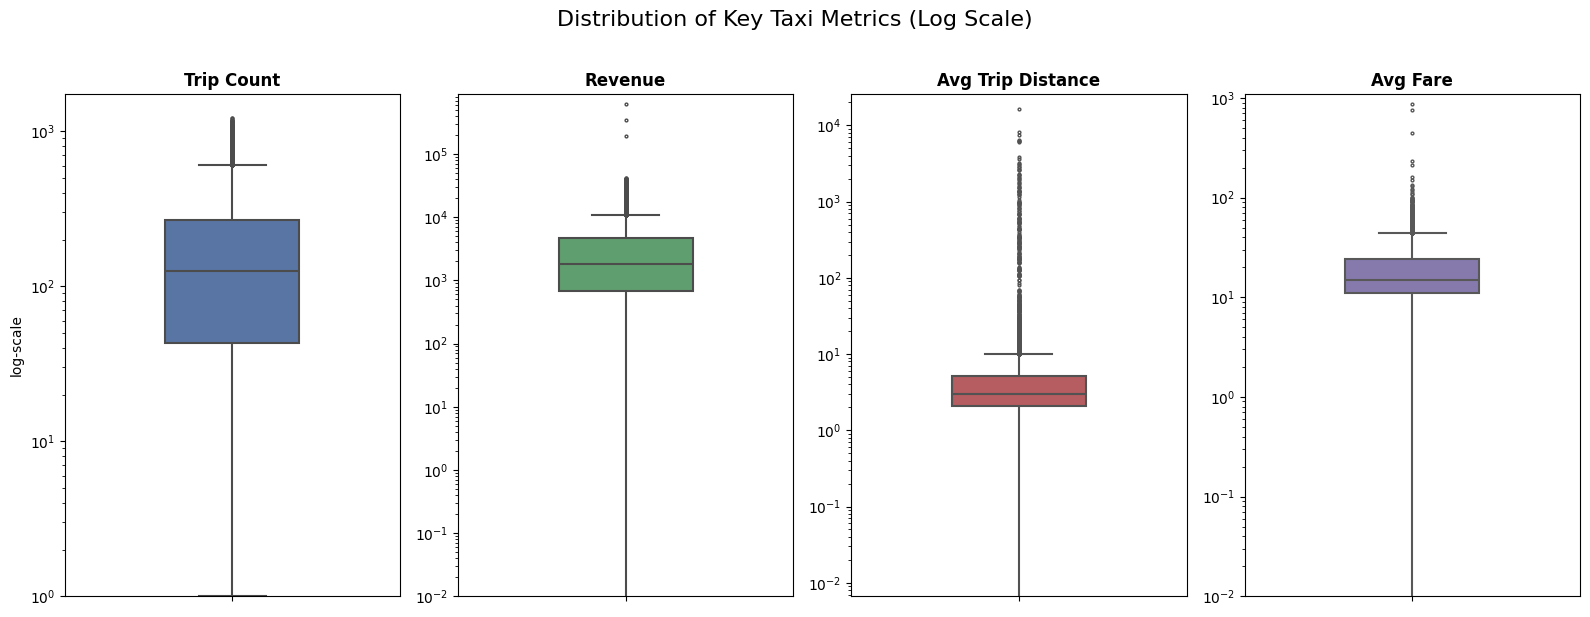

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define distinct colors for each variable
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
outlier_cols = ['trip_count', 'revenue', 'avg_trip_distance', 'avg_fare']

plot_df = merged_df[outlier_cols].copy()
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 6))

# Loop through to create boxplot for each metric
for ax, col, color in zip(axes, outlier_cols, colors):
    sns.boxplot(
        y=plot_df[col],
        ax=ax,
        color=color,
        width=0.4,
        linewidth=1.5,
        fliersize=2
    )

    ax.set_yscale("log")

    col_min = plot_df[col][plot_df[col] > 0].min()
    ax.set_ylim(bottom=col_min)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("log-scale" if ax == axes[0] else "") # Label only on first plot

plt.suptitle("Distribution of Key Taxi Metrics (Log Scale)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

The summary statistics and log-scale boxplots show that `trip_count` and `customers` are heavy-tailed but still fall within a range that looks reasonable for busy NYC zones. In contrast, `revenue`, `avg_trip_distance`, and `avg_fare` each have a small number of extremely large values that are far above their 99th percentiles, including impossible average distances and unrealistically high average fares. This suggests that most observations are clean, but there are a few clearly problematic hours driven by bad distance or fare records. In 2.4.2, we will introduce a targeted cleaning rule to handle these extreme cases without distorting the main demand patterns.


### 2.4.2 Choosing outlier thresholds

In [ ]:
# Targeted removal of clearly extreme outliers

clean_cols = ["revenue", "avg_trip_distance", "avg_fare"]

# Use a very high percentile as cutoff so we only remove the most extreme 0.1% tails
high_quantiles = merged_df[clean_cols].quantile(0.999)
high_quantiles

,0.999
revenue,32958.545860
avg_trip_distance,44.835169
avg_fare,68.126975


The 99.9th percentile cutoffs for `revenue`, `avg_trip_distance`, and `avg_fare` indicate that only an extremely small fraction (0.1%) of zone-hour observations lie in the extreme right tail of these distributions. Because these variables are derived from transactional taxi records that can occasionally contain data entry or aggregation errors (e.g., incorrectly recorded long trips or fares), we treat values beyond these thresholds as likely data artifacts rather than genuine economic extremes. By selecting such conservative cutoffs, we ensure that we remove only the most implausible observations while preserving essentially all legitimate high-demand periods in the dataset.

### 2.4.3 Handling extreme outliers

Based on the previous diagnostics, we now apply a targeted cleaning step to remove only the most clearly implausible observations. We focus on variables where we observed impossible or extremely unrealistic values:

- `revenue`
- `avg_trip_distance`
- `avg_fare`

For each of these metrics, we compute the 99.9th percentile and drop rows that exceed this cutoff. This removes a very small fraction of zone–hour records (the most extreme 0.1% of values) while keeping the overall demand signal (`trip_count`, `customers`) essentially unchanged. The resulting `merged_df` will be used as the cleaned base dataset for all subsequent analysis and modeling.


In [ ]:
# Targeted removal of extreme outliers in abnormal features

# Compute very high percentile cutoffs (99.9%) for these features
high_quantiles = merged_df[clean_cols].quantile(0.999)
print("99.9th percentile cutoffs for abnormal features:")
display(high_quantiles)

rows_before = len(merged_df)

# Keep rows where all three features are at or below their 99.9th percentile
mask = (
    (merged_df["revenue"]          <= high_quantiles["revenue"]) &
    (merged_df["avg_trip_distance"] <= high_quantiles["avg_trip_distance"]) &
    (merged_df["avg_fare"]         <= high_quantiles["avg_fare"])
)

merged_df_clean = merged_df[mask].reset_index(drop=True)

rows_after = len(merged_df_clean)
removed = rows_before - rows_after
pct_removed = removed / rows_before * 100

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Removed {removed:,} rows ({pct_removed:.4f}% of data)")

# Use cleaned dataset going forward
merged_df = merged_df_clean
del merged_df_clean


99.9th percentile cutoffs for abnormal features:


,0.999
revenue,32958.545860
avg_trip_distance,44.835169
avg_fare,68.126975


Rows before cleaning: 184,880
Rows after cleaning:  184,332
Removed 548 rows (0.2964% of data)


# Part 3: Exploratory Data Analysis (EDA)

## 3.1 Zone-level overview
We first compare average hourly taxi activity across our five focus pickup zones.  
This gives us a sense of the relative scale of demand by location and helps motivate why we keep location (`zone_full_name`, `borough`) as important categorical features in the models.


In [ ]:
merged_df

,zone_id,timestamp,customers,revenue,trip_count,avg_trip_distance,temperature,apparent_temperature,precipitation,rain,snowfall,cloudcover,windspeed,humidity,avg_fare,borough,zone_full_name,weathercode,date,year,month,dayofweek,hour,is_holiday,holiday_name,is_major_event,event_name
0,79,2019-01-01 06:00:00,178.0,1266.50,110,3.117091,57.4,50.7,0.000,0.000,0.0,89.0,19.5,91.0,11.513636,Manhattan,East Village,3,2019-01-01,2019,1,1,6,1,New Year's Day,0,None
1,79,2019-01-01 07:00:00,171.0,1355.00,100,3.817600,55.0,47.8,0.000,0.000,0.0,76.0,17.8,86.0,13.550000,Manhattan,East Village,2,2019-01-01,2019,1,1,7,1,New Year's Day,0,None
2,79,2019-01-01 08:00:00,88.0,797.00,59,3.753898,55.9,48.0,0.000,0.000,0.0,98.0,19.2,82.0,13.508475,Manhattan,East Village,3,2019-01-01,2019,1,1,8,1,New Year's Day,0,None
3,79,2019-01-01 09:00:00,124.0,895.00,86,2.486279,57.4,48.8,0.000,0.000,0.0,100.0,19.9,75.0,10.406977,Manhattan,East Village,3,2019-01-01,2019,1,1,9,1,New Year's Day,0,None
4,79,2019-01-01 10:00:00,155.0,979.18,102,2.334020,57.9,48.0,0.000,0.000,0.0,99.0,21.3,66.0,9.599804,Manhattan,East Village,3,2019-01-01,2019,1,1,10,1,New Year's Day,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184327,261,2024-12-31 18:00:00,58.0,705.90,43,3.135349,45.9,40.8,0.000,0.000,0.0,100.0,6.8,82.0,16.416279,Manhattan,World Trade Center,3,2024-12-31,2024,12,1,18,0,None,1,Times Sq NYE
184328,261,2024-12-31 19:00:00,48.0,538.45,35,2.842286,46.6,41.6,0.000,0.000,0.0,98.0,6.6,81.0,15.384286,Manhattan,World Trade Center,3,2024-12-31,2024,12,1,19,0,None,1,Times Sq NYE
184329,261,2024-12-31 20:00:00,43.0,486.46,34,2.981176,46.4,41.4,0.000,0.000,0.0,100.0,6.7,82.0,14.307647,Manhattan,World Trade Center,3,2024-12-31,2024,12,1,20,0,None,1,Times Sq NYE
184330,261,2024-12-31 21:00:00,30.0,503.90,37,2.993514,45.2,40.6,0.122,0.122,0.0,100.0,6.0,87.0,13.618919,Manhattan,World Trade Center,63,2024-12-31,2024,12,1,21,0,None,1,Times Sq NYE


In [ ]:
# 3.1 Prepare zone-level summary table

zone_summary = (
    merged_df
    .groupby(["zone_full_name", "borough"], as_index=False)
    .agg(
        mean_trip_count=("trip_count", "mean"),
        median_trip_count=("trip_count", "median"),
        mean_customers=("customers", "mean"),
        mean_revenue=("revenue", "mean"),
        mean_avg_fare=("avg_fare", "mean"),
        mean_trip_distance=("avg_trip_distance", "mean"),
        n_hours=("trip_count", "size"),
    )
)

zone_summary = zone_summary.sort_values("mean_trip_count", ascending=False)

display(zone_summary.round(2))



,zone_full_name,borough,mean_trip_count,median_trip_count,mean_customers,mean_revenue,mean_avg_fare,mean_trip_distance,n_hours
3,Upper East Side South,Manhattan,306.02,287.0,422.45,3232.69,10.57,1.90,37223
1,JFK Airport,Queens,234.46,218.0,358.03,12012.53,49.59,15.20,36722
2,Times Sq/Theatre District,Manhattan,187.44,164.0,283.26,2854.23,15.65,3.19,37190
0,East Village,Manhattan,114.76,86.0,160.16,1425.43,12.72,2.46,37174
4,World Trade Center,Manhattan,34.62,28.0,52.69,660.53,19.48,4.43,36023


### 3.1.1 Average hourly trip count by zone

We first look at the mean hourly `trip_count` in each pickup zone to see which locations consistently generate higher taxi demand.


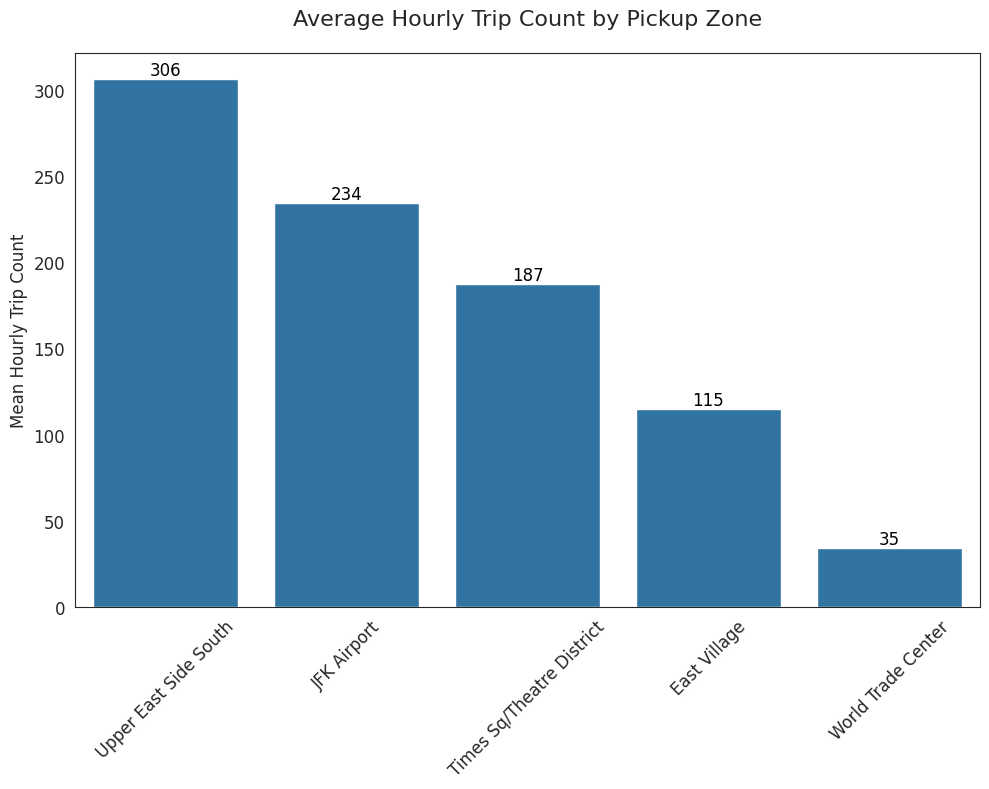

In [ ]:
# 1. Setup Style
sns.set_style("white")

# 2. Create the Plot (Following your vertical layout)
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=zone_summary,
    x="zone_full_name",
    y="mean_trip_count"
)

# 3. Refine Labels and Title
ax.set_title("Average Hourly Trip Count by Pickup Zone", pad=20, fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Mean Hourly Trip Count", size=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# 4. Add Data Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', color='black', size=12)

# 5. Show
plt.tight_layout()
plt.show()

The bar chart shows clear differences in average hourly trip counts across our five pickup zones. Upper East Side South records the highest mean demand (around 300 trips per hour), followed by JFK Airport and Times Sq/Theatre District, while East Village and especially World Trade Center see noticeably lower activity. These gaps indicate that pickup location is a major determinant of taxi demand, and we explicitly include zone information (e.g., `zone_full_name` / `zone_id` dummies) in our feature set to capture these systematic differences across areas.


### 3.1.2 Average hourly revenue by zone

We next compare the mean hourly `revenue` across pickup zones to understand how the economic value of trips varies by location.


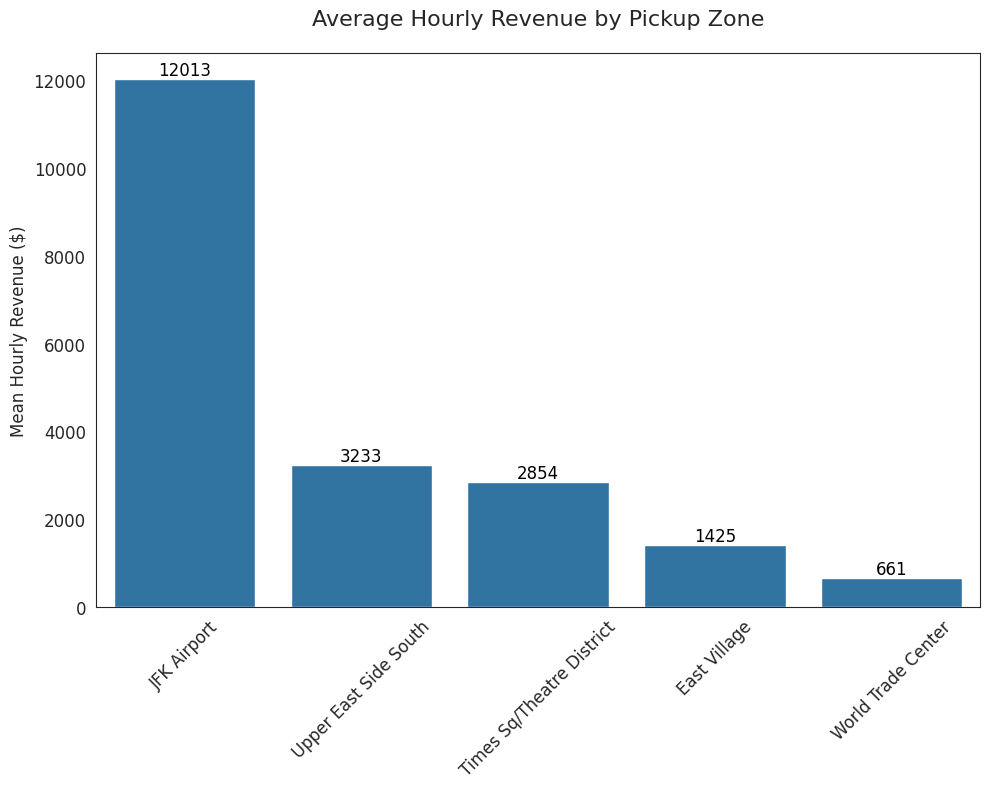

In [ ]:
# Sort Data by Revenue
zone_summary_sorted = zone_summary.sort_values("mean_revenue", ascending=False)

# 1. Setup Style
sns.set_style("white")

# 2. Create the Plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=zone_summary_sorted,
    x="zone_full_name",
    y="mean_revenue"
)

# 3. Refine Labels and Title
ax.set_title("Average Hourly Revenue by Pickup Zone", pad=20, fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Mean Hourly Revenue ($)", size=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# 4. Add Data Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', color='black', size=12)

# 5. Show
plt.tight_layout()
plt.show()

The revenue plot shows a much sharper separation across zones than the trip-count plot. JFK Airport stands out with by far the highest mean hourly revenue (around \$12k), more than three times that of Upper East Side South (around \$3.2k) and Times Sq/Theatre District (around \$2.9k). East Village and World Trade Center generate substantially less revenue per hour (around \$1.4k and around \$0.7k). This pattern is consistent with the nature of trips originating in each area: airport pickups tend to be longer, higher-fare journeys (often to other boroughs or Manhattan), whereas trips starting in dense Manhattan neighborhoods or the World Trade Center area are more likely to be shorter, intra-city rides.

These results highlight that pickup zone is not just a label but a strong driver of the underlying demand and revenue structure. Different zones operate at very different baseline levels of hourly ridership and fare volume, so our feature set explicitly encodes zone information (via `zone_id` / `zone_full_name`) to allow the later models to capture these systematic location effects.


## 3.2 Hour-of-day patterns

We next examine how hourly taxi demand varies over the course of the day.  
Understanding these diurnal patterns helps us see when demand typically peaks and how consistent those peaks are across our five pickup zones.


### 3.2.1 Average hourly trip count across all zones

We first aggregate all pickup zones together and look at the mean `trip_count` by hour of day to identify global peaks and troughs in demand.


,hour,mean_trip_count,median_trip_count,n_hours
0,6,59.435260,31.0,10573
1,7,94.461990,56.0,10721
2,8,116.131491,85.0,10822
3,9,128.133802,99.0,10822
4,10,140.865136,108.0,10885
5,11,153.346327,115.0,10903
6,12,171.046096,134.0,10912
7,13,184.359501,144.0,10904
8,14,208.974404,153.0,10900
9,15,214.445403,157.0,10898


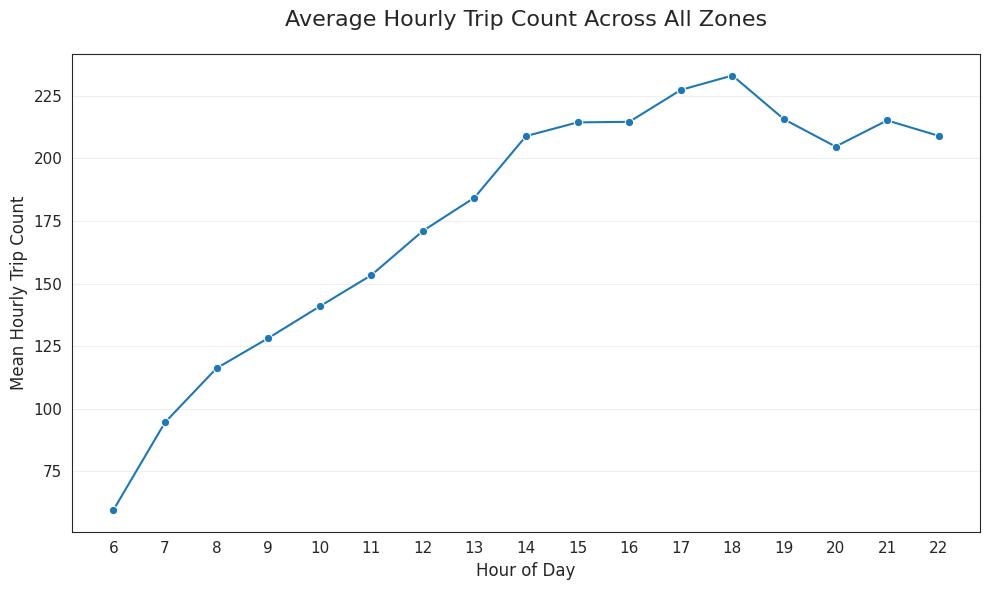

In [ ]:
# 3.2.1 Average hourly trip count across all zones

hourly_overall = (
    merged_df
    .groupby("hour", as_index=False)
    .agg(
        mean_trip_count=("trip_count", "mean"),
        median_trip_count=("trip_count", "median"),
        n_hours=("trip_count", "size")
    )
)

display(hourly_overall)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=hourly_overall,
    x="hour",
    y="mean_trip_count",
    marker="o"
)

ax.set_title("Average Hourly Trip Count Across All Zones", pad=20, fontsize=16)
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Mean Hourly Trip Count", fontsize=12)

plt.xticks(hourly_overall["hour"], fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The hourly profile shows a clear and smooth diurnal pattern. Across all five zones, demand starts relatively low around 6:00 (around 60 trips per hour), then increases steadily through the late morning and early afternoon. Trip counts cross 200 per hour by early afternoon and peak between 17:00 and 18:00 with around 230–235 trips per hour, before gradually declining into the evening. The gap between mean and median also widens during the afternoon and early evening, indicating more variability in busy hours. Overall, taxi activity is strongly structured by hour of day, with a pronounced build-up from morning to evening peak, so hour-of-day is a key time feature we carry forward in the modeling section.


### 3.2.2 Hour-of-day patterns by day of week

To dig deeper into the hourly profile, we now add the day of week as a second time dimension. This lets us see how the typical 24-hour demand level differs between weekdays and weekends.

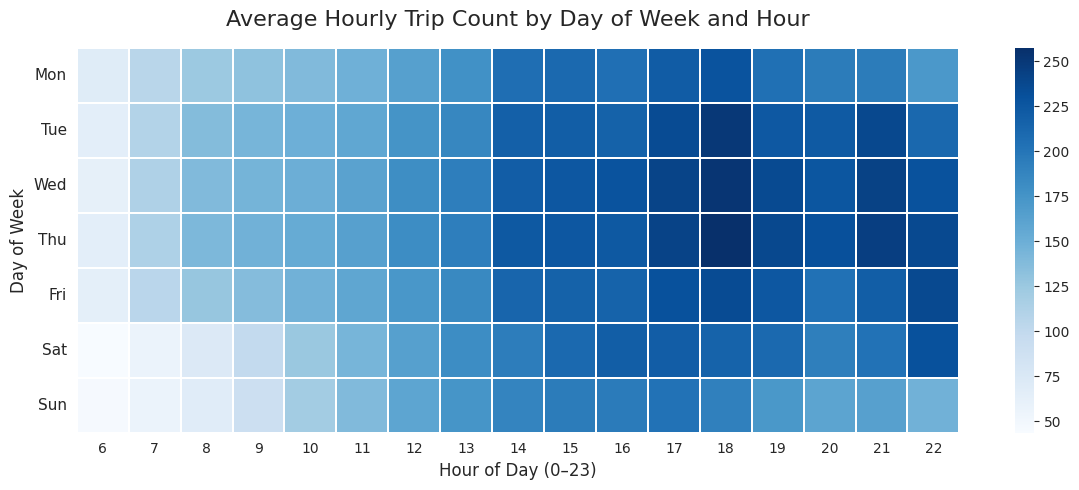

In [ ]:
# 3.2.2 Average hourly trip count by hour and day of week (all zones)

# Map numeric dayofweek (0–6) to short weekday names
day_name_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

# Work on a copy
tmp = merged_df.copy()
tmp["day_name"] = tmp["dayofweek"].map(day_name_map)

# Aggregate: mean trip_count for each (day_name, hour) combination
dow_hourly = (
    tmp
    .groupby(["day_name", "hour"], as_index=False)
    .agg(
        mean_trip_count=("trip_count", "mean"),
        n_hours=("trip_count", "size")
    )
)

# Reshape to a day x hour matrix for heatmap
dow_hourly_pivot = dow_hourly.pivot(
    index="day_name",
    columns="hour",
    values="mean_trip_count"
).loc[["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]]

# Plot heatmap of mean hourly trip count by day-of-week and hour
plt.figure(figsize=(12, 5))
ax = sns.heatmap(
    dow_hourly_pivot,
    cmap="Blues",
    linewidths=0.3,
    linecolor="white"
)

# Adjust colorbar label font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(12)
cbar.ax.tick_params(labelsize=10)

# Axis titles and labels
ax.set_title("Average Hourly Trip Count by Day of Week and Hour", pad=16, fontsize=16)
ax.set_xlabel("Hour of Day (0–23)", fontsize=12)
ax.set_ylabel("Day of Week", fontsize=12)

# Tick label formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()


The heatmap shows a very regular day–hour structure in demand. Across all days, hourly trip counts rise steadily from the morning into the afternoon, with the highest activity concentrated between about 15:00 and 19:00. Weekdays have very similar shapes, with Tuesday–Thursday showing the strongest evening peaks and Friday remaining elevated through the early evening. Saturday stays relatively busy into the evening but at a slightly lower level than the mid-week peak, while Sunday is noticeably lighter overall, especially in the morning and late evening.

Taken together with the overall hourly profile in 3.2.1, this confirms a strong interaction between hour of day and day of week: demand is not only higher in the late afternoon, but the strength and timing of that peak varies by day. We will therefore keep both `hour` and `dayofweek` as core time features and later experiment with encodings that allow the models to capture these recurring weekly patterns.

### 3.2.3 Hourly Patterns by Day-of-Week and Pickup Zone

Sections 3.2.1 and 3.2.2 showed that both **hour of day** and **day of week** are important drivers of demand when we average across zones.  
Here we put these dimensions together at the zone level and examine how the **hourly profile changes across days of the week** for each of our five pickup zones.



In [ ]:
# Preparation: mean hourly trip count by hour-of-day, day-of-week, and pickup zone

zone_col = "zone_full_name"   # adjust if your column name is different

day_name_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

tmp = merged_df.copy()
tmp["day_name"] = tmp["dayofweek"].map(day_name_map)

# Aggregate mean hourly trip_count for each (zone, day-of-week, hour)
hour_zone_dow = (
    tmp
    .groupby([zone_col, "day_name", "hour"], as_index=False)
    .agg(
        mean_trip_count=("trip_count", "mean"),
        n_obs=("trip_count", "size")
    )
)

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hour_zone_dow["day_name"] = pd.Categorical(
    hour_zone_dow["day_name"],
    categories=day_order,
    ordered=True
)

zone_order = [
    "East Village",
    "JFK Airport",
    "Times Sq/Theatre District",
    "Upper East Side South",
    "World Trade Center"
]
hour_zone_dow[zone_col] = pd.Categorical(
    hour_zone_dow[zone_col],
    categories=zone_order,
    ordered=True
)

hour_zone_dow = hour_zone_dow.sort_values([zone_col, "day_name", "hour"])

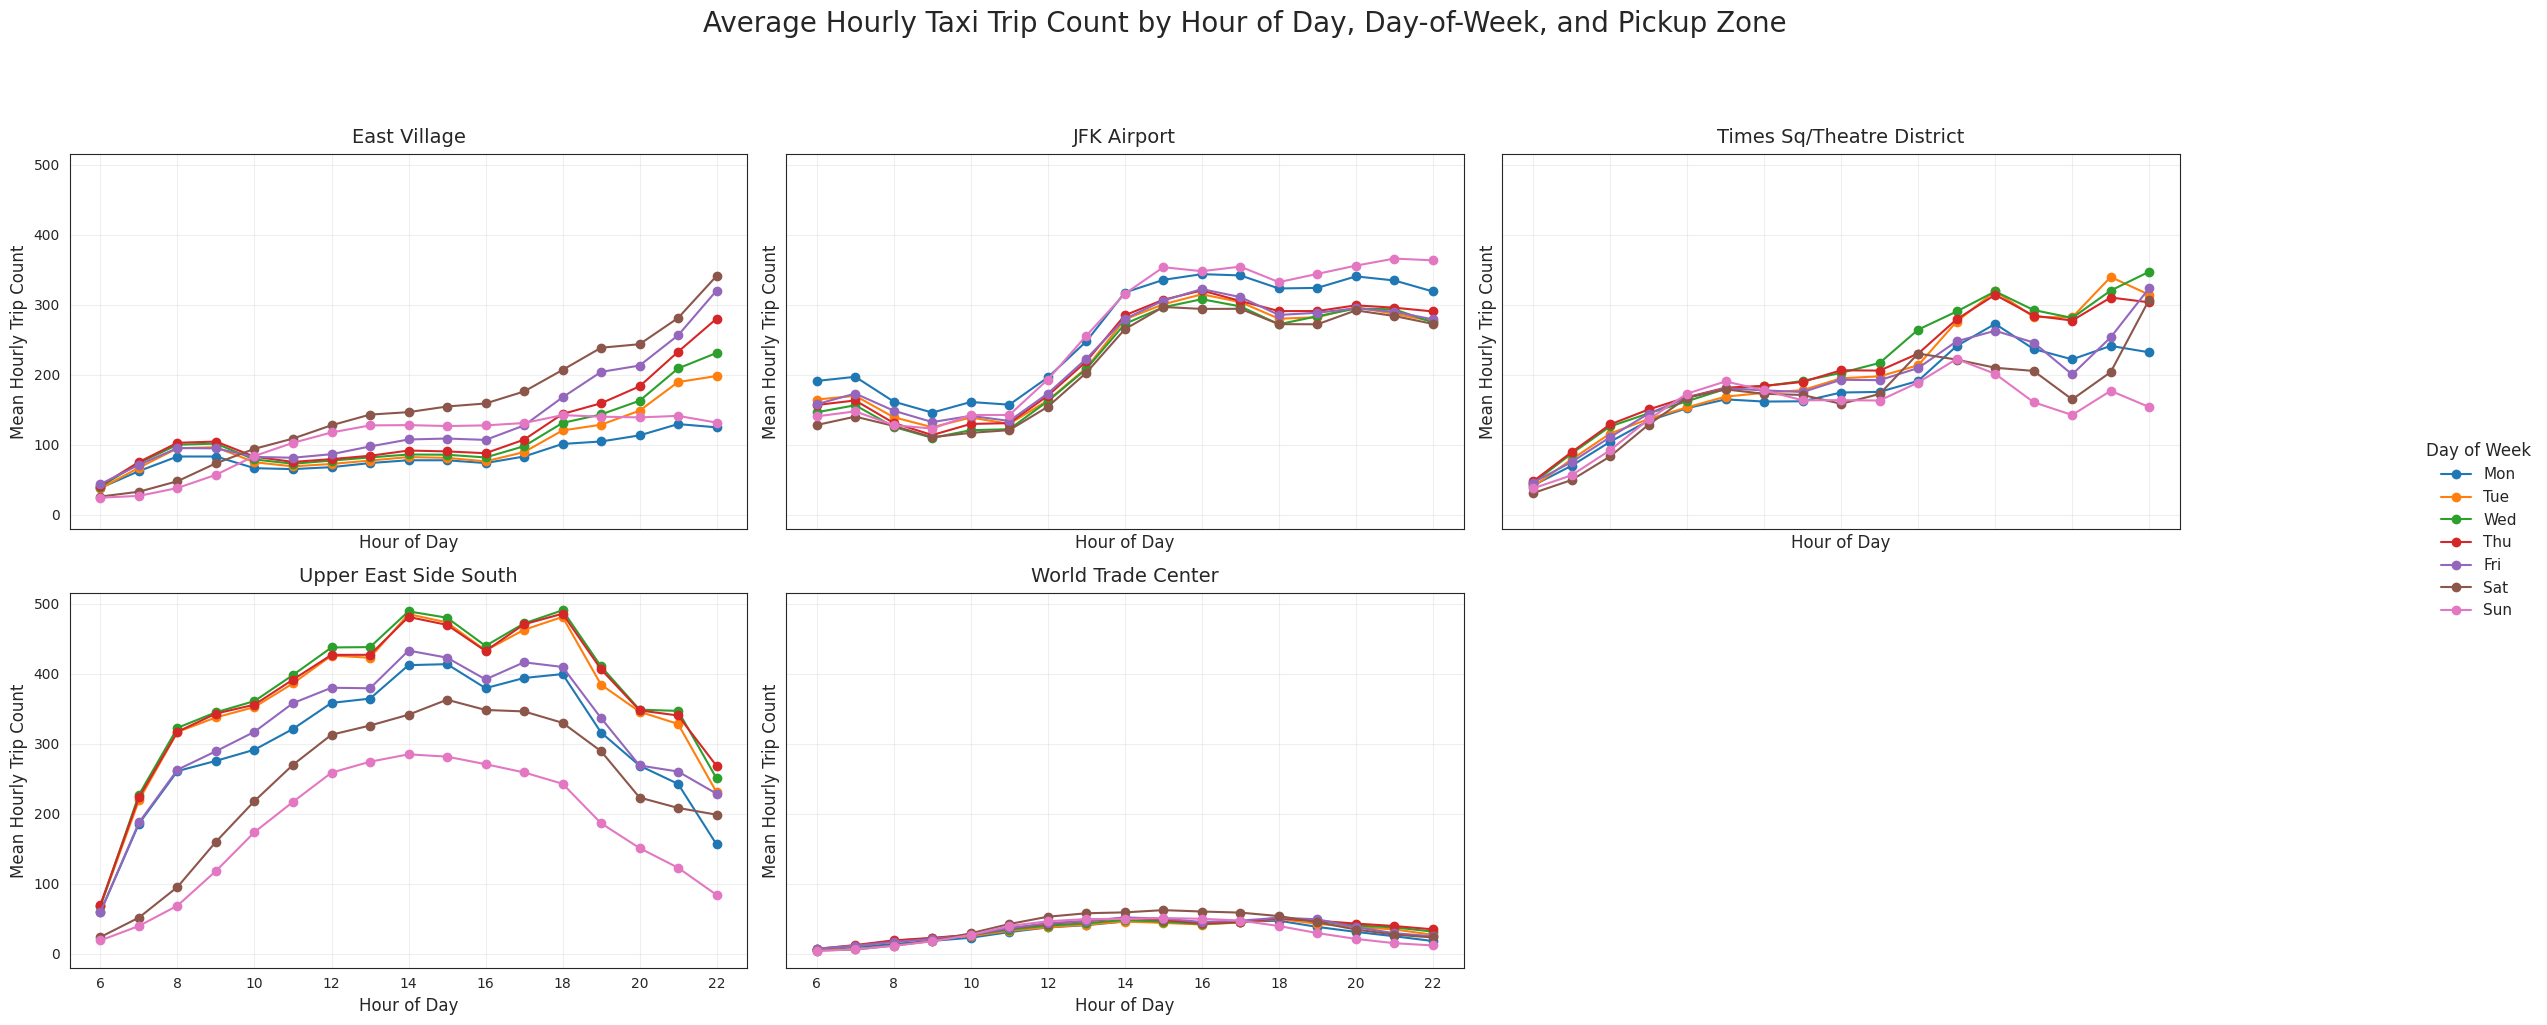

In [ ]:
#  Average Hourly Taxi Trip Count by Hour of Day, Day-of-Week, and Pickup Zone

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(25, 10),
    sharex=True,
    sharey=True
)
axes_flat = axes.flatten()

dow_color_map = {
    "Mon": "C0",
    "Tue": "C1",
    "Wed": "C2",
    "Thu": "C3",
    "Fri": "C4",
    "Sat": "C5",
    "Sun": "C6",
}

for ax, zone in zip(axes_flat, zone_order):
    zone_data = hour_zone_dow[hour_zone_dow[zone_col] == zone]
    for day in day_order:
        day_data = zone_data[zone_data["day_name"] == day]
        ax.plot(
            day_data["hour"],
            day_data["mean_trip_count"],
            marker="o",
            label=day,
            color=dow_color_map[day]
        )
    ax.set_title(zone, fontsize=14, pad=8)
    ax.set_xlabel("Hour of Day", fontsize=12)
    ax.set_ylabel("Mean Hourly Trip Count", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)

for ax in axes_flat[len(zone_order):]:
    ax.set_visible(False)

fig.suptitle(
    "Average Hourly Taxi Trip Count by Hour of Day, Day-of-Week, and Pickup Zone",
    fontsize=20,
    y=1.02
)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Day of Week",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()


Within each zone, the hourly shape is broadly similar across days, but the **level** of demand shifts with the day-of-week. East Village and Times Sq/Theatre District show stronger Saturday–Sunday evening peaks, consistent with leisure activity, whereas Upper East Side South is clearly more weekday-oriented with higher volumes from the morning commute through late afternoon. JFK Airport is relatively stable across days with only mild weekend uplift, and World Trade Center remains low throughout.

Taken together, the analyses in **3.2** show that taxi demand exhibits a strong and systematic **time structure**. At the citywide level (3.2.1), demand ramps up through the morning and peaks in the late afternoon/early evening. At the zone level (3.2.2–3.2.3), both the height and timing of these peaks depend on the pickup zone and, for some zones, on weekday versus weekend patterns. This supports including rich temporal features such as `hour`, `dayofweek`, and their interactions with `zone` in our forecasting models.



## 3.3 Temperature vs Demand
Weather is another factor that can systematically influence taxi usage. In this subsection we examine how **average hourly trip counts change across the temperature range**, aggregating over all zones and hours. This helps us see whether demand is highest on mild days and tends to drop off when it is very cold or very hot, which is important for deciding whether temperature should enter the forecasting model as a key feature.

In [ ]:
# Data Preparation
# Bin temperature into 2°F buckets to get a more detailed curve
bin_width = 2
merged_df["temp_bin"] = (
    (merged_df["temperature"] // bin_width) * bin_width
).astype("float")  # use the left edge of each 2°F bin as the bin label

# For each temperature bin, compute the average hourly demand
temp_demand_overall = (
    merged_df
    .groupby("temp_bin")
    .agg(
        mean_trip_count=("trip_count", "mean"),
        mean_customers=("customers", "mean"),
        n_obs=("trip_count", "size"),   # number of hourly observations in the bin
    )
    .reset_index()
    .sort_values("temp_bin")
)


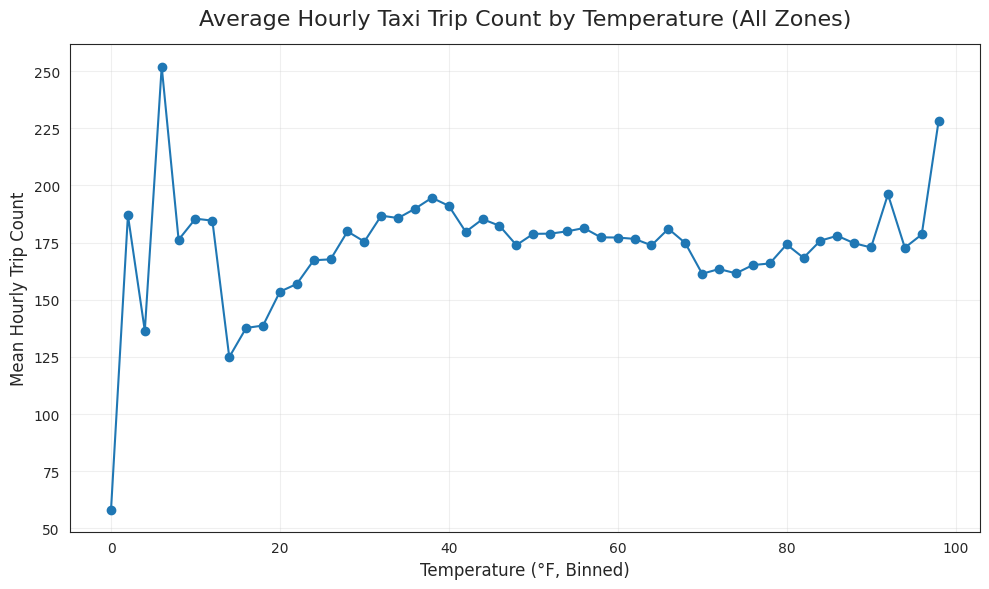

In [ ]:
# Plot
plt.figure(figsize=(10, 6))

# Line plot of mean hourly trip count against binned temperature
plt.plot(
    temp_demand_overall["temp_bin"],
    temp_demand_overall["mean_trip_count"],
    marker="o"
)

# Title and axis labels (capitalized to match our convention)
plt.title("Average Hourly Taxi Trip Count by Temperature (All Zones)",
          fontsize=16, pad=14)
plt.xlabel("Temperature (°F, Binned)", fontsize=12)
plt.ylabel("Mean Hourly Trip Count", fontsize=12)

# Ticks and grid for readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


The relationship between temperature and demand is non-linear. For most moderate temperatures (roughly 30°F–80°F), average hourly trip counts stay in a fairly tight band around 170–190, with only modest variation. In contrast, we see noticeably higher demand at the **coldest** and **hottest** temperatures in the sample: trips tend to be elevated near freezing and again at very warm conditions in the 90s. This pattern is consistent with riders substituting away from walking or public transit when the weather is uncomfortable, but the overall effect still appears smaller than the strong time-of-day, day-of-week, and zone pattern


## 3.4 Rain vs Demand

In addition to temperature, **precipitation** is a key weather factor that can change how people use taxis.  
Here we compare average hourly trip counts between **rainy** and **non-rainy** hours, broken out by pickup zone. This lets us see whether riders systematically switch to taxis when it is raining, and whether that effect is stronger in certain parts of the city.


In [ ]:
# Data Preparation

# Binary rain flag: 1 if it is raining in that hour, 0 otherwise
merged_df["is_raining"] = (merged_df["rain"] > 0).astype(int)

# Map to human-readable labels for plotting
rain_label_map = {0: "No Rain", 1: "Rain"}
merged_df["rain_label"] = merged_df["is_raining"].map(rain_label_map)

# Average hourly trip count by (zone, rain / no-rain)
rain_demand_by_zone = (
    merged_df
    .groupby(["zone_full_name", "rain_label"])
    .agg(
        mean_trip_count=("trip_count", "mean"),
        n_hours=("trip_count", "size")  # how many hourly observations per group
    )
    .reset_index()
)

# Ensure zones appear in a consistent order
zone_order = [
    "East Village",
    "JFK Airport",
    "Times Sq/Theatre District",
    "Upper East Side South",
    "World Trade Center",
]
rain_demand_by_zone["zone_full_name"] = pd.Categorical(
    rain_demand_by_zone["zone_full_name"],
    categories=zone_order,
    ordered=True
)

rain_demand_by_zone = rain_demand_by_zone.sort_values(
    ["zone_full_name", "rain_label"]
)


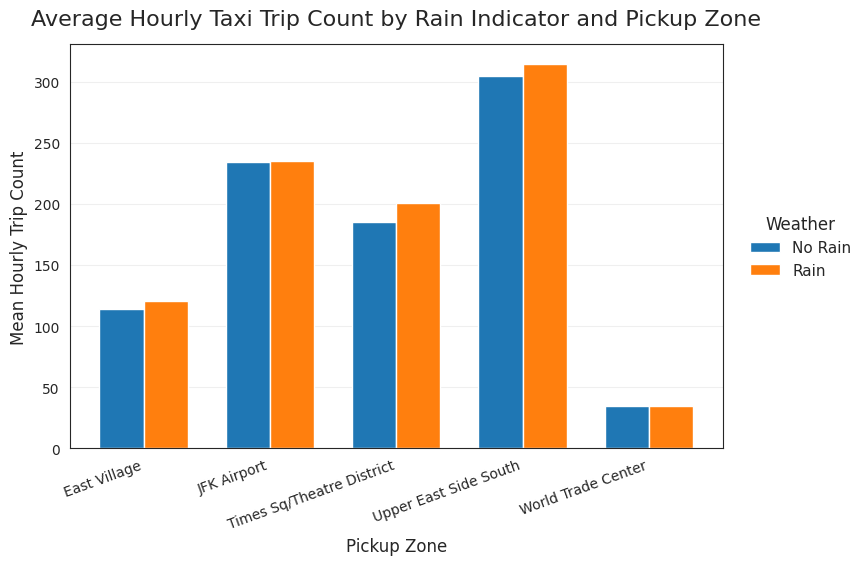

In [ ]:
# Plot

plt.figure(figsize=(10, 6))

# Grouped bar chart: Rain vs No Rain for each pickup zone
x = np.arange(len(zone_order))  # zone positions
width = 0.35                    # bar width

no_rain = rain_demand_by_zone[rain_demand_by_zone["rain_label"] == "No Rain"]
rain = rain_demand_by_zone[rain_demand_by_zone["rain_label"] == "Rain"]

plt.bar(x - width / 2, no_rain["mean_trip_count"], width, label="No Rain")
plt.bar(x + width / 2, rain["mean_trip_count"], width, label="Rain")

plt.title("Average Hourly Taxi Trip Count by Rain Indicator and Pickup Zone",
          fontsize=16, pad=14)
plt.xlabel("Pickup Zone", fontsize=12)
plt.ylabel("Mean Hourly Trip Count", fontsize=12)

plt.xticks(x, zone_order, rotation=20, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Weather",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()


Rain is associated with a modest but consistent increase in taxi demand in most zones.  
East Village, Times Sq/Theatre District, and Upper East Side South all show higher mean
hourly trip counts during rainy hours than during dry hours, with the uplift most visible
in the denser residential/commuter zones (Times Sq and Upper East Side South). In
contrast, JFK Airport and World Trade Center show almost no difference between rain and
no-rain conditions, suggesting that airport and business-district trips are driven more by
fixed travel needs than by weather. Overall, rain appears to be a **positive but
zone-dependent** demand shifter, reinforcing its value as a weather control in the model.

## 3.5 Holiday vs Demand

Beyond regular weekday/weekend patterns, certain **holidays** can generate unusual
surges or drops in taxi demand. In this subsection we compare **average hourly trip
counts on holidays versus non-holidays**. This gives a
compact view of whether holidays are generally associated with higher taxi usage in
our sample, and motivates including a holiday indicator in the forecasting model.


In [ ]:
# Data preparation

# Map the binary holiday flag to readable labels
holiday_label_map = {0: "Non-Holiday", 1: "Holiday"}

tmp = merged_df.copy()
tmp["holiday_label"] = tmp["is_holiday"].map(holiday_label_map)

# Average hourly trip count by (zone, holiday / non-holiday)
holiday_demand_by_zone = (
    tmp
    .groupby(["zone_full_name", "holiday_label"])
    .agg(
        mean_trip_count=("trip_count", "mean"),
        n_hours=("trip_count", "size")  # number of hourly observations per group
    )
    .reset_index()
)

# Ensure zones appear in a consistent order (same as earlier sections)
zone_order = [
    "East Village",
    "JFK Airport",
    "Times Sq/Theatre District",
    "Upper East Side South",
    "World Trade Center",
]
holiday_demand_by_zone["zone_full_name"] = pd.Categorical(
    holiday_demand_by_zone["zone_full_name"],
    categories=zone_order,
    ordered=True
)

holiday_demand_by_zone = holiday_demand_by_zone.sort_values(
    ["zone_full_name", "holiday_label"]
)


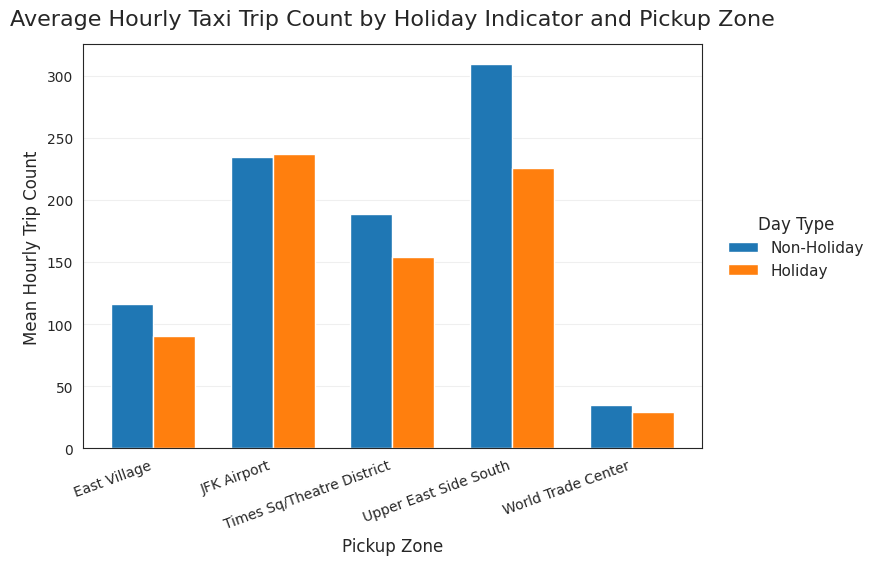

In [ ]:
# Plot

plt.figure(figsize=(10, 6))

# Positions for grouped bars
x = np.arange(len(zone_order))
width = 0.35

non_holiday = holiday_demand_by_zone[
    holiday_demand_by_zone["holiday_label"] == "Non-Holiday"
].set_index("zone_full_name")["mean_trip_count"]

holiday = holiday_demand_by_zone[
    holiday_demand_by_zone["holiday_label"] == "Holiday"
].set_index("zone_full_name")["mean_trip_count"]

# Draw bars for non-holiday and holiday side by side
plt.bar(x - width / 2, non_holiday[zone_order], width, label="Non-Holiday")
plt.bar(x + width / 2, holiday[zone_order], width, label="Holiday")

plt.title("Average Hourly Taxi Trip Count by Holiday Indicator and Pickup Zone",
          fontsize=16, pad=14)
plt.xlabel("Pickup Zone", fontsize=12)
plt.ylabel("Mean Hourly Trip Count", fontsize=12)

plt.xticks(x, zone_order, rotation=20, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Day Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()


Holidays do not have a uniform effect across zones. In East Village, Times Sq/Theatre District, and especially Upper East Side South, average hourly trip counts are **lower on holidays** than on regular days, suggesting that commuter and routine trips drop more than leisure trips rise. World Trade Center is also slightly quieter on holidays, consistent with reduced business activity. By contrast, JFK Airport looks almost unchanged (if anything, marginally higher), which fits the idea that air travel follows its own calendar. Overall, holidays appear to **reshape demand more by reducing activity in residential and office-heavy zones** than by creating large positive spikes, supporting the use of a holiday indicator mainly as a correction for lower-than-usual volumes in certain areas.

## 3.6 Correlation Matrix


###3.6.1 Create the correlation matrix
To bridge the EDA with our modeling choices, we next look at how the **main numeric
variables move together**. A correlation matrix lets us (i) see which predictors are most
strongly associated with `trip_count`, and (ii) flag pairs of variables that are highly
correlated with each other and may cause multicollinearity in linear models. The insights
here will guide both feature selection and the interpretation of regression coefficients
later on.


In [ ]:
# Select key numeric features (target + candidate predictors)
num_cols = [
    "trip_count",
    "customers",
    "revenue",
    "avg_trip_distance",
    "avg_fare",
    "temperature",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "cloudcover",
    "windspeed",
    "humidity",
    "hour",
    "dayofweek",
    "month",
    "is_holiday",
    "is_major_event",
    "is_raining",
]

# Subset to these columns and drop any rows with missing values
corr_df = merged_df[num_cols].dropna()

# Compute Pearson correlation matrix
corr_matrix = corr_df.corr()

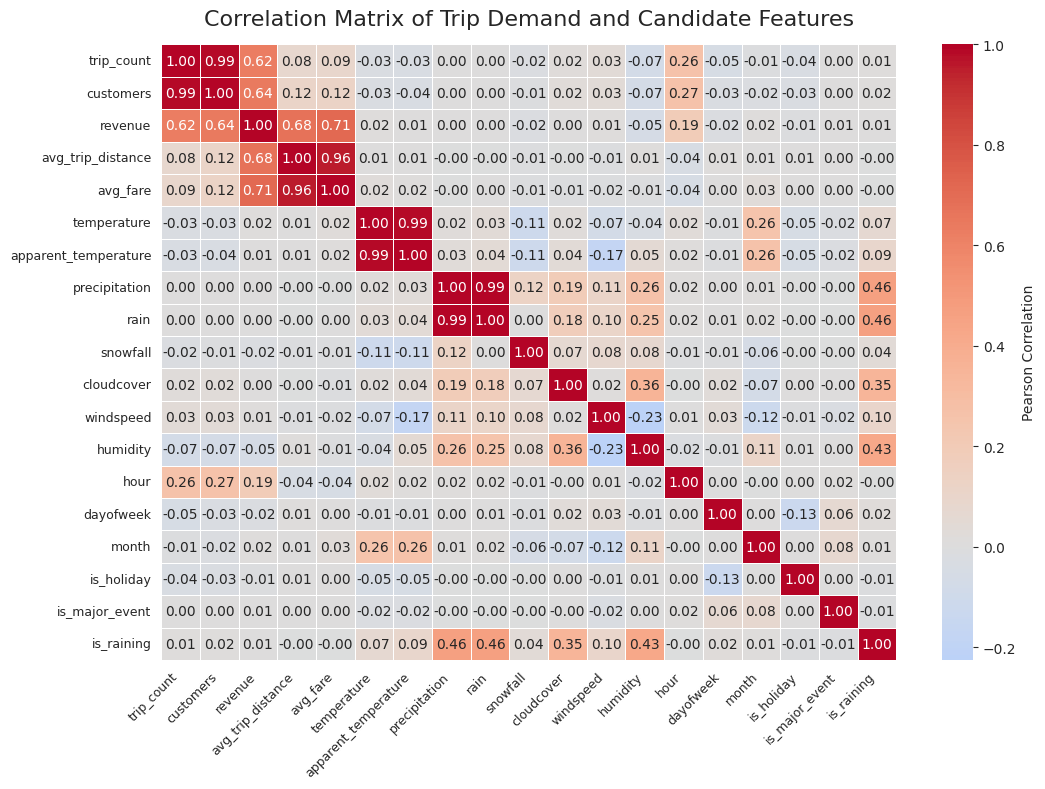

In [ ]:
# Plot Correlation Matrix

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Matrix of Trip Demand and Candidate Features",
          fontsize=16, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

The correlation matrix highlights a few clear patterns and helps us decide which numeric
features to keep for modeling. `trip_count` is almost perfectly aligned with `customers`
(0.99) and strongly correlated with `revenue` (0.62), so we treat `trip_count` as the
sole demand target and **do not use `customers` or `revenue` as predictors**. On the
trip-characteristics side, `avg_trip_distance` and `avg_fare` are almost perfectly
correlated (0.96); we keep **`avg_trip_distance`** as the main control for trip length
and **drop `avg_fare`** to avoid redundancy. Weather variables also show strong internal
correlations: `temperature` and `apparent_temperature` (0.99), and `precipitation`,
`rain`, and `is_raining` (0.99 and 0.46). To keep the feature set interpretable while
avoiding multicollinearity, we keep **`temperature` and `precipitation`** as our main
continuous weather signals and **drop `apparent_temperature`, `rain`, and `is_raining`,
as well as the engineered `temp_bin` and `rain_label` columns** that were only needed
for EDA. The remaining numeric features (`avg_trip_distance`, weather variables,
calendar flags such as `hour`, `dayofweek`, `month`, `is_holiday`, `is_major_event`)
form the core set we will carry into our baseline models.


### 3.6.2 Feature decisions based on correlation matrix

In [ ]:
# Columns we drop because they are alternative demand measures or highly redundant
drop_for_model = [
    "customers",            # alternative demand measure, almost same as trip_count
    "revenue",              # revenue is also tightly linked to trip_count
    "avg_fare",             # almost perfectly correlated with avg_trip_distance
    "apparent_temperature", # almost perfectly correlated with temperature
    "rain",                 # highly correlated with precipitation / is_raining
    "is_raining",           # engineered from rain
    "temp_bin",             # engineered for EDA only
    "rain_label",           # engineered for EDA only
]

# Create a modeling copy of the dataframe with redundant numeric columns removed
model_df = merged_df.drop(columns=drop_for_model)

# For reference: core numeric features we plan to use in baseline models
core_numeric_features = [
    "trip_count",          # target
    "avg_trip_distance",
    "temperature",
    "precipitation",
    "snowfall",
    "cloudcover",
    "windspeed",
    "humidity",
    "hour",
    "dayofweek",
    "month",
    "is_holiday",
    "is_major_event",
]

print("Columns dropped from modeling dataset:")
print(drop_for_model)

print("\nCore numeric features retained for modeling:")
print(core_numeric_features)

model_df[core_numeric_features].head()


Columns dropped from modeling dataset:
['customers', 'revenue', 'avg_fare', 'apparent_temperature', 'rain', 'is_raining', 'temp_bin', 'rain_label']

Core numeric features retained for modeling:
['trip_count', 'avg_trip_distance', 'temperature', 'precipitation', 'snowfall', 'cloudcover', 'windspeed', 'humidity', 'hour', 'dayofweek', 'month', 'is_holiday', 'is_major_event']


,trip_count,avg_trip_distance,temperature,precipitation,snowfall,cloudcover,windspeed,humidity,hour,dayofweek,month,is_holiday,is_major_event
0,110,3.117091,57.4,0.0,0.0,89.0,19.5,91.0,6,1,1,1,0
1,100,3.817600,55.0,0.0,0.0,76.0,17.8,86.0,7,1,1,1,0
2,59,3.753898,55.9,0.0,0.0,98.0,19.2,82.0,8,1,1,1,0
3,86,2.486279,57.4,0.0,0.0,100.0,19.9,75.0,9,1,1,1,0
4,102,2.334020,57.9,0.0,0.0,99.0,21.3,66.0,10,1,1,1,0


These removals were guided by the correlation matrix to prevent multicollinearity from inflating variance in the linear regression baseline and to stabilize the tree-based feature splits.

### 3.7 Demand Persistence Over Time

Considering characteristics of time-series data, we observed that the hourly and daily plots in Section 3.2 suggest that demand is persistent over time:
busy hours tend to be followed by other busy hours in the same zone, and daily patterns
repeat. To quantify this, we examine the **autocorrelation of `trip_count`** at
lag 1 hour, lag 24 hours (same hour yesterday), and lag 168 hours (same hour last week)
for each pickup zone. This will guide the choice of lag features later in our models.


In [ ]:
# Data preparation

# Work on a sorted copy to respect time ordering
ac_df = merged_df.sort_values(["zone_id", "timestamp"]).copy()

lags = [1, 24, 168]
lag_labels = {1: "Lag 1h", 24: "Lag 24h", 168: "Lag 168h"}

rows = []

for zone in ac_df["zone_full_name"].unique():
    zdf = ac_df[ac_df["zone_full_name"] == zone].copy()
    for l in lags:
        zdf[f"trip_count_lag_{l}h"] = (
            zdf["trip_count"].shift(l)
        )
        corr = zdf["trip_count"].corr(zdf[f"trip_count_lag_{l}h"])
        rows.append({
            "zone_full_name": zone,
            "lag": l,
            "lag_label": lag_labels[l],
            "autocorr": corr
        })

autocorr_df = pd.DataFrame(rows)
autocorr_df


,zone_full_name,lag,lag_label,autocorr
0,East Village,1,Lag 1h,0.760382
1,East Village,24,Lag 24h,0.295952
2,East Village,168,Lag 168h,0.443619
3,JFK Airport,1,Lag 1h,0.882402
4,JFK Airport,24,Lag 24h,0.293913
5,JFK Airport,168,Lag 168h,0.745347
6,Times Sq/Theatre District,1,Lag 1h,0.811899
7,Times Sq/Theatre District,24,Lag 24h,0.485003
8,Times Sq/Theatre District,168,Lag 168h,0.583734
9,Upper East Side South,1,Lag 1h,0.917217


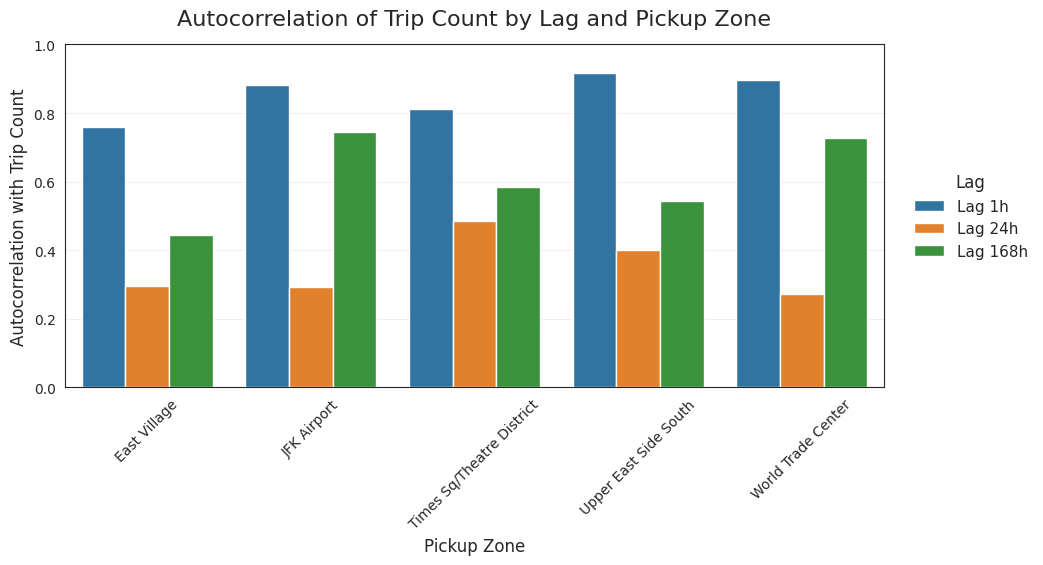

In [ ]:
# Plot

plt.figure(figsize=(12, 6))

sns.barplot(
    data=autocorr_df,
    x="zone_full_name",
    y="autocorr",
    hue="lag_label"
)

plt.title("Autocorrelation of Trip Count by Lag and Pickup Zone",
          fontsize=16, pad=14)
plt.xlabel("Pickup Zone", fontsize=12)
plt.ylabel("Autocorrelation with Trip Count", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1)  # autocorrelation coefficients between 0 and 1 here
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Lag",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()


The autocorrelation plot confirms that demand is strongly persistent over time. In every
zone, lag 1 hour shows the highest autocorrelation, indicating that the previous hour’s
demand is a very strong predictor of the current hour. Lag 168 hours (same hour last
week) is also clearly positive and generally stronger than lag 24 hours, which suggests a
meaningful weekly pattern on top of the daily cycle. Lag 24 hours remains positive but is
noticeably weaker, especially in some zones, implying that “same hour yesterday” carries
information but less than the immediate past hour or the same hour last week. Taken
together, these patterns justify adding lag 1h, lag 24h, and lag 168h—along with a short
moving-average trend feature—as demand history features in our models next.

## Part 4: Feature Engineering & Targets

## 4.1 Feature Engineering

We now translate the EDA findings into a set of engineered features that capture the main
temporal patterns in demand while avoiding redundant variables flagged.
These features will serve as the common input space for all models in Section 4.


### 4.1.1 Time-Based Features

Given the strong hour-of-day and day-of-week effects, we enrich
the raw calendar fields by adding **cyclical encodings** for `hour`, `dayofweek`, and
`month`, along with a simple **weekend indicator**. These features allow models to learn
smooth periodic patterns (e.g., the daily demand cycle) without treating adjacent times
as unrelated categories.

In [ ]:
# 4.1.1 Time-Based Features

fe_df = model_df.copy()

# Cyclical encoding for hour of day (period = 24)
fe_df["hour_sin"] = np.sin(2 * np.pi * fe_df["hour"] / 24)
fe_df["hour_cos"] = np.cos(2 * np.pi * fe_df["hour"] / 24)

# Cyclical encoding for day of week (period = 7)
fe_df["dow_sin"] = np.sin(2 * np.pi * fe_df["dayofweek"] / 7)
fe_df["dow_cos"] = np.cos(2 * np.pi * fe_df["dayofweek"] / 7)

# Cyclical encoding for month of year (period = 12)
fe_df["month_sin"] = np.sin(2 * np.pi * fe_df["month"] / 12)
fe_df["month_cos"] = np.cos(2 * np.pi * fe_df["month"] / 12)

# Weekend indicator: Saturday (5) or Sunday (6)
fe_df["is_weekend"] = fe_df["dayofweek"].isin([5, 6]).astype(int)

fe_df[[
    "hour", "hour_sin", "hour_cos",
    "dayofweek", "dow_sin", "dow_cos",
    "month", "month_sin", "month_cos",
    "is_weekend"
]].head()


,hour,hour_sin,hour_cos,dayofweek,dow_sin,dow_cos,month,month_sin,month_cos,is_weekend
0,6,1.000000,6.123234e-17,1,0.781831,0.62349,1,0.5,0.866025,0
1,7,0.965926,-2.588190e-01,1,0.781831,0.62349,1,0.5,0.866025,0
2,8,0.866025,-5.000000e-01,1,0.781831,0.62349,1,0.5,0.866025,0
3,9,0.707107,-7.071068e-01,1,0.781831,0.62349,1,0.5,0.866025,0
4,10,0.500000,-8.660254e-01,1,0.781831,0.62349,1,0.5,0.866025,0


### 4.1.2 Demand History Features

Section 3.7 showed that taxi demand is highly persistent over time: the previous hour,
the same hour yesterday, and the same hour last week all have clear positive
autocorrelation with current demand. To let our models use this “memory”, we construct
zone-level history features based on `trip_count`:

- `trip_count_lag_1h`: demand in the previous hour (short-term persistence).
- `trip_count_lag_24h`: demand 24 hours earlier (same hour yesterday).
- `trip_count_lag_168h`: demand 168 hours earlier (same hour last week).
- `trip_count_ma_4h`: a 4-hour moving average of past demand, summarizing the recent
  trend while smoothing out hour-to-hour noise.

All features are computed within each `zone_id` and use only past information, so they
are suitable as predictors in a forecasting setting.

In [ ]:
# Make sure data are ordered by zone and time
fe_df = fe_df.sort_values(["zone_id", "timestamp"])

# Convenience handle for the series we will lag/roll within each zone
zone_trip_counts = fe_df.groupby("zone_id")["trip_count"]

# Lag features (memory)
fe_df["trip_count_lag_1h"] = zone_trip_counts.shift(1)     # previous hour
fe_df["trip_count_lag_24h"] = zone_trip_counts.shift(24)   # same hour yesterday
fe_df["trip_count_lag_168h"] = zone_trip_counts.shift(168) # same hour last week

# Moving-average trend: 4-hour rolling mean using only past values
past_trip_count = zone_trip_counts.shift(1)
fe_df["trip_count_ma_4h"] = (
    past_trip_count
    .rolling(window=4, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

fe_df[[
    "zone_id",
    "timestamp",
    "trip_count",
    "trip_count_lag_1h",
    "trip_count_lag_24h",
    "trip_count_lag_168h",
    "trip_count_ma_4h"
]].head(10)


,zone_id,timestamp,trip_count,trip_count_lag_1h,trip_count_lag_24h,trip_count_lag_168h,trip_count_ma_4h
0,79,2019-01-01 06:00:00,110,NaN,NaN,NaN,NaN
1,79,2019-01-01 07:00:00,100,110.0,NaN,NaN,110.000000
2,79,2019-01-01 08:00:00,59,100.0,NaN,NaN,105.000000
3,79,2019-01-01 09:00:00,86,59.0,NaN,NaN,89.666667
4,79,2019-01-01 10:00:00,102,86.0,NaN,NaN,88.750000
5,79,2019-01-01 11:00:00,152,102.0,NaN,NaN,86.750000
6,79,2019-01-01 12:00:00,151,152.0,NaN,NaN,99.750000
7,79,2019-01-01 13:00:00,175,151.0,NaN,NaN,122.750000
8,79,2019-01-01 14:00:00,193,175.0,NaN,NaN,145.000000
9,79,2019-01-01 15:00:00,211,193.0,NaN,NaN,167.750000


The lag and moving-average features introduced in 4.1.2 are not defined for the very
first timestamps in each zone (for example, we cannot look 168 hours back at the start
of the series). These rows show up as `NaN` in `trip_count_lag_1h`, `trip_count_lag_24h`,
`trip_count_lag_168h`, and `trip_count_ma_4h`.

Since we have several years of hourly data, we adopt a simple and transparent approach:
for modeling, we **drop rows where any of the history features are missing**. This
removes only the initial hours in each zone (roughly the first week), while ensuring that
every training example has a complete set of lag and trend features.


In [ ]:
# Handling Missing Values from History Features

history_cols = [
    "trip_count_lag_1h",
    "trip_count_lag_24h",
    "trip_count_lag_168h",
    "trip_count_ma_4h",
]

before_rows = len(fe_df)

# Keep only rows where all history features are present
fe_df = fe_df.dropna(subset=history_cols)

after_rows = len(fe_df)

print(f"Rows before dropping history-NaNs: {before_rows:,}")
print(f"Rows after dropping history-NaNs : {after_rows:,}")
print(f"Rows removed                     : {before_rows - after_rows:,}")

fe_df[["zone_id", "timestamp"] + history_cols].head()


Rows before dropping history-NaNs: 184,332
Rows after dropping history-NaNs : 183,492
Rows removed                     : 840


,zone_id,timestamp,trip_count_lag_1h,trip_count_lag_24h,trip_count_lag_168h,trip_count_ma_4h
168,79,2019-01-10 21:00:00,460.0,151.0,110.0,322.50
169,79,2019-01-10 22:00:00,565.0,167.0,100.0,412.25
170,79,2019-01-11 06:00:00,534.0,143.0,59.0,470.25
171,79,2019-01-11 07:00:00,118.0,166.0,86.0,419.25
172,79,2019-01-11 08:00:00,190.0,266.0,102.0,351.75


### 4.1.3 One-Hot Encoded Categorical Features

Finally, we convert the key categorical identifiers into a numeric format that models can
use. In our dataset, the main categorical variable is `zone_full_name`, which
distinguishes the five pickup zones. We create a set of **one-hot encoded dummy
variables** for `zone_full_name`, so that the model can learn zone-specific demand
levels and interactions with time and weather. We keep the original `zone_full_name`
column for grouping and diagnostics, but will rely on the dummy variables as inputs in
the modeling step.


In [ ]:
# One-Hot Encoded Categorical Features

# Categorical feature to encode
categorical_cols = ["zone_full_name"]

# Create one-hot dummies for pickup zones
zone_dummies = pd.get_dummies(
    fe_df["zone_full_name"],
    prefix="zone",
    drop_first=False   # keep all dummies; we can drop one later for linear models if needed
)

# Attach dummies to the feature-engineered dataframe
fe_df = pd.concat([fe_df, zone_dummies], axis=1)

# Store the list of dummy columns for later use in modeling
zone_dummy_cols = zone_dummies.columns.tolist()

print("Zone dummy columns created:")
print(zone_dummy_cols)

fe_df[["zone_full_name"] + zone_dummy_cols].head()


Zone dummy columns created:
['zone_East Village', 'zone_JFK Airport', 'zone_Times Sq/Theatre District', 'zone_Upper East Side South', 'zone_World Trade Center']


,zone_full_name,zone_East Village,zone_JFK Airport,zone_Times Sq/Theatre District,zone_Upper East Side South,zone_World Trade Center
168,East Village,True,False,False,False,False
169,East Village,True,False,False,False,False
170,East Village,True,False,False,False,False
171,East Village,True,False,False,False,False
172,East Village,True,False,False,False,False


### 4.1.4 Final Datasets for Reference and Modeling

At this point, we have a full feature-engineered table that includes:

- the target `trip_count`,
- calendar and weather features,
- demand history features (lags and moving average),
- and one-hot zone dummies (with East Village as the implicit reference).

In [ ]:
fe_df_full = fe_df.copy()
print("fe_df_full shape (reference):", fe_df_full.shape)
fe_df_full.head()


fe_df_full shape (reference): (183492, 38)


,zone_id,timestamp,trip_count,avg_trip_distance,temperature,precipitation,snowfall,cloudcover,windspeed,humidity,borough,zone_full_name,weathercode,date,year,month,dayofweek,hour,is_holiday,holiday_name,is_major_event,event_name,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,trip_count_lag_1h,trip_count_lag_24h,trip_count_lag_168h,trip_count_ma_4h,zone_East Village,zone_JFK Airport,zone_Times Sq/Theatre District,zone_Upper East Side South,zone_World Trade Center
168,79,2019-01-10 21:00:00,565,2.514425,30.6,0.0,0.0,96.0,10.9,59.0,Manhattan,East Village,3,2019-01-10,2019,1,3,21,0,None,0,None,-0.707107,7.071068e-01,0.433884,-0.900969,0.5,0.866025,0,460.0,151.0,110.0,322.50,True,False,False,False,False
169,79,2019-01-10 22:00:00,534,2.464757,30.7,0.0,0.0,100.0,15.8,55.0,Manhattan,East Village,3,2019-01-10,2019,1,3,22,0,None,0,None,-0.500000,8.660254e-01,0.433884,-0.900969,0.5,0.866025,0,565.0,167.0,100.0,412.25,True,False,False,False,False
170,79,2019-01-11 06:00:00,118,2.118220,22.2,0.0,0.0,6.0,11.1,51.0,Manhattan,East Village,0,2019-01-11,2019,1,4,6,0,None,0,None,1.000000,6.123234e-17,-0.433884,-0.900969,0.5,0.866025,0,534.0,143.0,59.0,470.25,True,False,False,False,False
171,79,2019-01-11 07:00:00,190,2.216842,22.3,0.0,0.0,7.0,14.1,51.0,Manhattan,East Village,0,2019-01-11,2019,1,4,7,0,None,0,None,0.965926,-2.588190e-01,-0.433884,-0.900969,0.5,0.866025,0,118.0,166.0,86.0,419.25,True,False,False,False,False
172,79,2019-01-11 08:00:00,270,2.019370,21.6,0.0,0.0,22.0,13.2,50.0,Manhattan,East Village,1,2019-01-11,2019,1,4,8,0,None,0,None,0.866025,-5.000000e-01,-0.433884,-0.900969,0.5,0.866025,0,190.0,266.0,102.0,351.75,True,False,False,False,False


Starting from the full feature-engineered table (`fe_df_full`), we now create a compact
dataset that will be used only for modeling. This `model_df` keeps:

- the target:
  - `trip_count`
- numeric predictors:
  - trip characteristics, weather, calendar flags, time encodings, and demand history
- zone dummies:
  - `zone_JFK Airport`, `zone_Times Sq/Theatre District`,
    `zone_Upper East Side South`, `zone_World Trade Center`
- In addition, we will keep `timestamp` first for train-test split but will drop it after the split

We treat **East Village** as the reference zone, so we do **not** include
`zone_East Village` as a predictor. High-level string columns such as `borough`,
`zone_full_name`, `weathercode`, `holiday_name`, and `event_name` are kept in
`fe_df_full` for reference but excluded from `modeling_df`.

In [ ]:
# Final Modeling Dataset

# 1) Keep the full feature-engineered dataframe for reference
fe_df_full = fe_df_full.copy()

# 2) Target column
target_col = "trip_count"

# 3) Numeric predictor features (manually selected)
numeric_features = [
    "temperature",
    "precipitation",
    "snowfall",
    "cloudcover",
    "windspeed",
    "humidity",
    "is_holiday",
    "is_major_event",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "trip_count_lag_1h",
    "trip_count_lag_24h",
    "trip_count_lag_168h",
    "trip_count_ma_4h",
]

# 4) Zone dummy features
# East Village is the reference category, so its dummy is NOT used as a predictor.
zone_dummy_features = [
    "zone_JFK Airport",
    "zone_Times Sq/Theatre District",
    "zone_Upper East Side South",
    "zone_World Trade Center",
]

# 5) Temporary timestamp
timestamp_col = "timestamp"

# 6) Combine all predictor columns for modeling
feature_cols_model = numeric_features + zone_dummy_features

# 7) Build the compact modeling dataset
model_df = fe_df_full[[target_col] + feature_cols_model + [timestamp_col]].copy().reset_index(drop=True)

print("modeling_df shape (for models):", model_df.shape)
print("\nColumns in modeling_df:")
print(model_df.columns.tolist())

model_df.head()


modeling_df shape (for models): (183492, 25)

Columns in modeling_df:
['trip_count', 'temperature', 'precipitation', 'snowfall', 'cloudcover', 'windspeed', 'humidity', 'is_holiday', 'is_major_event', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'trip_count_lag_1h', 'trip_count_lag_24h', 'trip_count_lag_168h', 'trip_count_ma_4h', 'zone_JFK Airport', 'zone_Times Sq/Theatre District', 'zone_Upper East Side South', 'zone_World Trade Center', 'timestamp']


,trip_count,temperature,precipitation,snowfall,cloudcover,windspeed,humidity,is_holiday,is_major_event,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,trip_count_lag_1h,trip_count_lag_24h,trip_count_lag_168h,trip_count_ma_4h,zone_JFK Airport,zone_Times Sq/Theatre District,zone_Upper East Side South,zone_World Trade Center,timestamp
0,565,30.6,0.0,0.0,96.0,10.9,59.0,0,0,0,-0.707107,7.071068e-01,0.433884,-0.900969,0.5,0.866025,460.0,151.0,110.0,322.50,False,False,False,False,2019-01-10 21:00:00
1,534,30.7,0.0,0.0,100.0,15.8,55.0,0,0,0,-0.500000,8.660254e-01,0.433884,-0.900969,0.5,0.866025,565.0,167.0,100.0,412.25,False,False,False,False,2019-01-10 22:00:00
2,118,22.2,0.0,0.0,6.0,11.1,51.0,0,0,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.5,0.866025,534.0,143.0,59.0,470.25,False,False,False,False,2019-01-11 06:00:00
3,190,22.3,0.0,0.0,7.0,14.1,51.0,0,0,0,0.965926,-2.588190e-01,-0.433884,-0.900969,0.5,0.866025,118.0,166.0,86.0,419.25,False,False,False,False,2019-01-11 07:00:00
4,270,21.6,0.0,0.0,22.0,13.2,50.0,0,0,0,0.866025,-5.000000e-01,-0.433884,-0.900969,0.5,0.866025,190.0,266.0,102.0,351.75,False,False,False,False,2019-01-11 08:00:00


## 4.2 Time-Based Train–Validation–Test Split

Because we are forecasting taxi demand over time, we use a **time-based split** rather
than a random split. All observations up to the end of 2022 are used for training,
the year 2023 is held out as a validation period for model selection and tuning, and
all remaining observations (2024 onward) form a final test set. This setup mimics the
real-world forecasting setting, where models are always applied to future periods that
were not seen during training.


In [ ]:
# Time-based train / validation / test split

# Define date boundaries
train_end   = pd.Timestamp('2022-12-31 23:59:59')
valid_end   = pd.Timestamp('2023-12-31 23:59:59')

# Create split masks
train_mask = model_df['timestamp'] <= train_end
valid_mask = (model_df['timestamp'] > train_end) & (model_df['timestamp'] <= valid_end)
test_mask  = model_df['timestamp'] > valid_end

# Split into three DataFrames
train_df = model_df[train_mask].reset_index(drop=True)
valid_df = model_df[valid_mask].reset_index(drop=True)
test_df  = model_df[test_mask].reset_index(drop=True)

print("\nTrain period     :", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Validation period:", valid_df["timestamp"].min(), "→", valid_df["timestamp"].max())
print("Test period      :", test_df["timestamp"].min(), "→", test_df["timestamp"].max())

# Finally, drop the timestamp column
train_df = train_df.drop(columns=[timestamp_col])
valid_df = valid_df.drop(columns=[timestamp_col])
test_df  = test_df.drop(columns=[timestamp_col])

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)



Train period     : 2019-01-10 21:00:00 → 2022-12-31 22:00:00
Validation period: 2023-01-01 06:00:00 → 2023-12-31 22:00:00
Test period      : 2024-01-01 06:00:00 → 2024-12-31 22:00:00
Train shape: (121815, 24)
Validation shape: (30776, 24)
Test shape: (30901, 24)


### 4.2.1 Constructing feature matrices and targets

In [ ]:
# Build X / y for train, validation, test

# Regression target: continuous hourly demand
y_train = train_df['trip_count']
y_valid = valid_df['trip_count']
y_test  = test_df['trip_count']

# Exclude regression target, classification target, and timestamp from features
feature_cols = [c for c in train_df.columns if c not in ['trip_count']]

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test  = test_df[feature_cols]

print("Number of features:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)
print("y_test shape:", y_test.shape)


Number of features: 23
X_train shape: (121815, 23)
X_valid shape: (30776, 23)
X_test shape: (30901, 23)
y_train shape: (121815,)
y_valid shape: (30776,)
y_test shape: (30901,)


The final regression design matrix contains 23 engineered features, with 121,815 training observations, 30,776 validation observations, and 30,901 test observations. The target variable (`trip_count`) is well populated and evenly aligned across splits. The large sample size and consistent feature dimensionality across time periods provide a strong foundation for stable model training, reliable hyperparameter tuning, and robust out-of-sample evaluation. The scale of the dataset also justifies the use of ensemble methods such as Random Forest and XGBoost, which benefit from large training sets.

# Part 5: Modeling

## 5.0 Modeling overview

Our modeling goal is to forecast **hourly taxi demand (`trip_count`)**
for each zone using weather, calendar, and recent-demand features, while
respecting the time-series structure of the data.

We first:
1. Split the data into train / validation / test sets by time
   (2019–2022 train, 2023 validation, 2024 test).
2. Scale only the numerical features when needed (for linear regression).
3. Train three baseline regression models:
   - Linear Regression (as a simple, interpretable benchmark),
   - Random Forest Regressor,
   - XGBoost Regressor.

We evaluate all models using RMSE, MAE, and R² on both validation and test
sets, then focus our tuning efforts on the best-performing tree-based model.


## 5.1 Scaling Numerical Features



### 5.1.1 Create a scaled version of the data using StandardScaler
Our predictors live on very different scales: temperatures are in degrees, windspeed in
miles per hour, lags in trip counts, and the trigonometric time encodings are already in
[-1, 1]. To make the optimization for linear and regularized models more stable, and to
ensure that no single large-scale variable dominates purely due to its units, we
**standardize the continuous numeric features**.

We fit the scaler **only on the training set** and then apply the same transformation to
the validation and test sets to avoid any information leak from the future. Binary flags
(`is_holiday`, `is_major_event`, `is_weekend`) and the zone dummies are left in their
0/1 form.

In [ ]:
# Continuous numeric features to standardize
# (binary flags and zone dummies are excluded)
numerical_features = [
    "temperature",
    "precipitation",
    "snowfall",
    "cloudcover",
    "windspeed",
    "humidity",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "trip_count_lag_1h",
    "trip_count_lag_24h",
    "trip_count_lag_168h",
    "trip_count_ma_4h",
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

X_valid_scaled = X_valid.copy()
X_valid_scaled[numerical_features] = scaler.transform(X_valid[numerical_features])

X_test_scaled = X_test.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

### 5.1.2 Summary of preprocessing pipeline

Our modeling pipeline follows a standard but robust structure designed for time-series tabular data:

1. **Feature engineering and cleaning**  
   We start from a fully cleaned and enriched panel with demand, weather, calendar, and zone indicators, and augment it with cyclic time encodings and lagged demand features.

2. **Time-based train–validation–test split**  
   Instead of random splits, we respect temporal order: 2019–2022 for training, 2023 for validation/tuning, and 2024 as an unseen test period. This prevents information from the future leaking into the training process.

3. **Scaling of continuous predictors**  
   For models that are sensitive to feature scale (e.g., linear regression), we standardize only the continuous numeric variables based on the training set and apply the same transformation to validation and test sets. Binary indicators and one-hot dummies remain in their 0/1 form.

4. **Baseline modeling and evaluation**  
   We fit a simple linear regression benchmark, followed by non-linear tree-based models (Random Forest and XGBoost), and evaluate them using RMSE, MAE, and R² on both validation and test sets.

5. **Hyperparameter tuning and interpretation**  
   For the best-performing tree model, we run a targeted hyperparameter search, then interpret the fitted model via feature importances and predicted-vs-actual plots. In a second step, we reuse the same feature set to predict KMeans-based demand regimes (Low/Medium/High) with a Random Forest classifier.


## 5.2 Baseline regression models

We deliberately choose three complementary regression models:

- **Linear Regression** serves as a simple, interpretable benchmark. It assumes an additive, linear relationship between predictors and hourly demand and provides a baseline level of performance to beat.

- **Random Forest Regressor** introduces non-linearity and interaction effects by aggregating many decision trees. It is robust to outliers, handles mixed-scale features well, and tends to perform strongly on tabular data without extensive tuning.

- **XGBoost Regressor** is a gradient-boosted tree model that typically pushes performance beyond Random Forests on structured data. It can capture subtle interactions and non-linearities while allowing fine-grained control over regularization and model complexity via hyperparameters.

Comparing these three models allows us to quantify how much predictive accuracy we gain by moving from a purely linear specification to more flexible tree-based methods, and to check whether additional complexity is justified by out-of-sample performance.


### 5.2.1 Common evaluation helper

In [ ]:
def evaluate_regression_model(name, y_true_valid, y_pred_valid, y_true_test, y_pred_test):
    """
    Print RMSE, MAE, and R^2 for validation and test sets
    for easier model comparison.
    """
    # Validation
    mse_valid = mean_squared_error(y_true_valid, y_pred_valid)
    rmse_valid = np.sqrt(mse_valid)
    mae_valid = mean_absolute_error(y_true_valid, y_pred_valid)
    r2_valid = r2_score(y_true_valid, y_pred_valid)

    # Test
    mse_test = mean_squared_error(y_true_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_true_test, y_pred_test)
    r2_test = r2_score(y_true_test, y_pred_test)

    print(f"{name}")
    print(f"  Validation RMSE: {rmse_valid:.2f} | MAE: {mae_valid:.2f} | R^2: {r2_valid:.3f}")
    print(f"  Test       RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f} | R^2: {r2_test:.3f}")

### 5.2.2 Linear Regression (baseline)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_valid_pred_lin = lin_reg.predict(X_valid_scaled)
y_test_pred_lin  = lin_reg.predict(X_test_scaled)

evaluate_regression_model("Linear Regression (scaled features)", y_valid, y_valid_pred_lin, y_test,  y_test_pred_lin)

Linear Regression (scaled features)
  Validation RMSE: 54.48 | MAE: 37.79 | R^2: 0.831
  Test       RMSE: 60.67 | MAE: 40.85 | R^2: 0.812


### 5.2.3 Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)

rf.fit(X_train, y_train)

y_valid_pred_rf = rf.predict(X_valid)
y_test_pred_rf  = rf.predict(X_test)

evaluate_regression_model("Random Forest (baseline)", y_valid, y_valid_pred_rf, y_test,  y_test_pred_rf)


Random Forest (baseline)
  Validation RMSE: 33.84 | MAE: 22.37 | R^2: 0.935
  Test       RMSE: 38.36 | MAE: 25.23 | R^2: 0.925


### 5.2.4 XGBoost

In [ ]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=400, n_jobs=-1)

xgb.fit(X_train, y_train)

y_valid_pred_xgb = xgb.predict(X_valid)
y_test_pred_xgb  = xgb.predict(X_test)

evaluate_regression_model("XGBoost (baseline)", y_valid, y_valid_pred_xgb, y_test,  y_test_pred_xgb)

XGBoost (baseline)
  Validation RMSE: 32.12 | MAE: 21.39 | R^2: 0.941
  Test       RMSE: 36.41 | MAE: 24.13 | R^2: 0.932


### 5.2.5 Baseline model comparison

Across our three baseline regressors, we see a clear performance ranking:

- **Linear Regression (scaled features)** achieves a validation RMSE of roughly 49 and R² around 0.831.  
  This confirms that a simple linear model can already explain a large share of the variance in hourly trip counts using time, weather, and lagged features, but it leaves substantial nonlinear structure unmodeled.

- **Random Forest** reduces validation RMSE to ~33 and increases R² to ~0.935, with similar performance on the test set.  
  This suggests that nonlinear interactions (e.g., between hour-of-day, day-of-week, and weather conditions) are important for demand and are well captured by tree ensembles.

- **XGBoost** performs slightly better than Random Forest, with validation RMSE in the ~32 range and test R² around 0.941.  
  The gain is modest but consistent, indicating that gradient boosting is able to squeeze out extra signal from the same feature set.

Overall, the gap between Linear Regression and the tree-based models shows that hourly taxi demand is strongly nonlinear in our features. Random Forest and XGBoost both perform well and generalize similarly from validation to test, so in the next section we focus on **hyperparameter tuning** these two families to see whether we can further reduce forecast error.


## 5.3 Hyperparameter tuning for XGBoost (RandomizedSearchCV with TimeSeriesSplit)

### 5.3.1 Search setup (RandomizedSearchCV + TimeSeriesSplit)

In [ ]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 400, 600],
                                        'subsample': [0.7, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best XGB params (RandomizedSearchCV):", xgb_random.best_params_)
print("Best CV RMSE (XGB):", -xgb_random.best_score_)

Best XGB params (RandomizedSearchCV): {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE (XGB): 56.39011859893799


In [ ]:
best_xgb = xgb_random.best_estimator_

y_valid_pred_xgb_tuned = best_xgb.predict(X_valid)
y_test_pred_xgb_tuned  = best_xgb.predict(X_test)

evaluate_regression_model("XGBoost (tuned via RandomizedSearchCV)", y_valid, y_valid_pred_xgb_tuned, y_test,  y_test_pred_xgb_tuned)

XGBoost (tuned via RandomizedSearchCV)
  Validation RMSE: 38.12 | MAE: 26.49 | R^2: 0.917
  Test       RMSE: 41.63 | MAE: 28.69 | R^2: 0.911


### 5.3.2 Tuning results and comparison to baseline

We next attempted to improve the baseline XGBoost model using RandomizedSearchCV with a TimeSeriesSplit (5 folds) on the training period (2019–2022). The search varied the number of trees (`n_estimators ∈ {200, 400, 600}`), tree depth (`max_depth ∈ {3, 5, 7}`), learning rate (`{0.01, 0.05, 0.1}`), subsampling and column sampling rates (`subsample`, `colsample_bytree ∈ {0.7, 0.9, 1.0}`), and `min_child_weight ∈ {1, 3, 5}`. The best configuration under the CV objective (-RMSE) selected relatively shallow trees and conservative sampling (e.g., `subsample=0.7`, `colsample_bytree=0.7`, `max_depth=3`, `learning_rate=0.05`), and achieved a best cross-validated RMSE of about **56.4** on the training folds.

When we refit this tuned model on the full training set and evaluate it on the held-out periods, however, performance deteriorates relative to the baseline. On validation, RMSE increases to 38.1 (MAE 26.5, R²=0.917), and on the test set RMSE rises to 41.6 (MAE 28.7, R²=0.911). In other words, the random search finds a more heavily regularized model that does well under the internal CV splits but underfits the higher-demand years of 2023–2024. Because the tuned configuration does not improve, we retain the simpler baseline XGBoost model as our final regressor and use the tuning exercise mainly to confirm that our original hyperparameters were already close to a good bias–variance trade-off.

### 5.3.3 XGBoost feature importances

Top 20 XGBoost feature importances:
trip_count_lag_1h                 0.643723
trip_count_ma_4h                  0.143686
trip_count_lag_168h               0.067420
hour_sin                          0.066051
trip_count_lag_24h                0.015534
zone_Upper East Side South        0.013848
zone_JFK Airport                  0.013415
hour_cos                          0.010682
zone_Times Sq/Theatre District    0.007729
is_weekend                        0.007282
dow_sin                           0.004817
dow_cos                           0.000924
month_cos                         0.000759
is_holiday                        0.000629
precipitation                     0.000618
cloudcover                        0.000593
temperature                       0.000534
humidity                          0.000465
windspeed                         0.000449
snowfall                          0.000443
dtype: float32


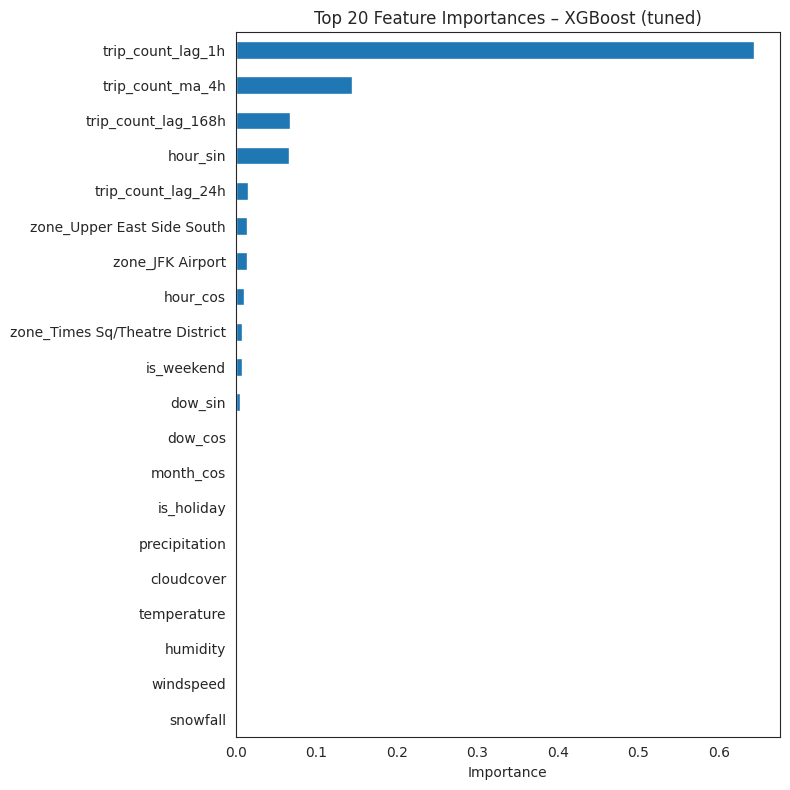

In [ ]:
xgb_importances = pd.Series(
    best_xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Top 20 XGBoost feature importances:")
print(xgb_importances.head(20))

plt.figure(figsize=(8, 8))
xgb_importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances – XGBoost (tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

The feature importance ranking confirms that short-horizon demand persistence dominates hourly taxi demand forecasting. The most influential predictors are `trip_count_lag_1h`, `trip_count_ma_4h`, and `trip_count_lag_168h`, indicating strong intraday and weekly autocorrelation. Cyclical time encodings `(hour_sin`, `hour_cos`) also contribute meaningfully, capturing daily demand rhythms. Spatial heterogeneity appears through zone indicators such as Upper East Side South, JFK Airport, and Times Square, while calendar effects (`is_weekend`, `is_holiday`) and weather variables enter as weaker but still informative modifiers. Overall, the model primarily relies on demand history and recurring temporal structure, with exogenous factors providing secondary refinements.

### 5.3.4 Predicted vs actual for tuned XGBoost (test set)


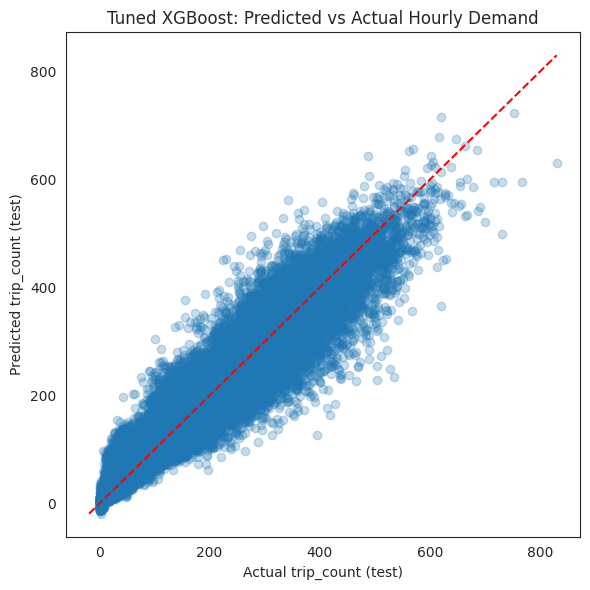

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_xgb_tuned, alpha=0.25)
lims = [min(y_test.min(), y_test_pred_xgb_tuned.min()),
        max(y_test.max(), y_test_pred_xgb_tuned.max())]
plt.plot(lims, lims, "r--")  # 45-degree line
plt.xlabel("Actual trip_count (test)")
plt.ylabel("Predicted trip_count (test)")
plt.title("Tuned XGBoost: Predicted vs Actual Hourly Demand")
plt.tight_layout()
plt.show()

The predicted-versus-actual scatter plot shows a tight concentration of points around the 45-degree reference line across most of the demand range, indicating strong calibration and low systematic bias. Prediction accuracy is highest in the low-to-medium demand regime, where the density of observations is greatest. At very high demand levels, some modest under-prediction is visible, consistent with the regularization imposed during hyperparameter tuning. Nevertheless, the overall dispersion remains limited, confirming that the tuned XGBoost model captures both the central tendency and the variability of hourly taxi demand with high fidelity.

## 5.4 Hyperparameter tuning for Random Forest via successive halving

For Random Forest, we use successive halving (HalvingRandomSearchCV) instead of GridSearchCV or RandomizedSearchCV because of the computational structure of tree ensembles and the scale of our dataset. A full grid search over tree depth, split rules, and feature subsampling would require training hundreds of large forests on over 120,000 observations, which is computationally infeasible. While RandomizedSearchCV is more efficient than grid search, it still allocates roughly the same training budget to every sampled configuration, even when many of them perform poorly early on.

Successive halving is better suited to Random Forest because model performance improves monotonically as the number of trees increases. HalvingRandomSearchCV exploits this by training many candidate models using small forests at first, quickly discarding weak configurations, and progressively allocating more trees only to the most promising ones. This allows us to explore a wide hyperparameter space efficiently while concentrating computation where it matters most.

We intentionally pair this with RandomizedSearchCV for XGBoost because gradient boosting does not exhibit the same monotonic training behavior as bagged trees. As a result, early-stage performance is less predictive of final performance for XGBoost than for Random Forest. Our tuning strategy is therefore algorithm-aware rather than uniform across models.


### 5.4.1 HalvingRandomSearchCV setup for Random Forest

In [ ]:
# Base Random Forest (same random_state / n_jobs as before)
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space:
# - We tune depth, split/leaf sizes, and feature subsampling.
rf_param_dist = {
    "max_depth": randint(8, 32),
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", 0.5],
}

# TimeSeriesSplit to preserve temporal ordering during CV
tscv_rf = TimeSeriesSplit(n_splits=3)

# Successive halving: resource = n_estimators (number of trees)
rf_halving_search = HalvingRandomSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    factor=3,                        # how aggressively we cut bad configs
    resource="n_estimators",         # RF "budget" = number of trees
    max_resources=600,               # max trees for the best configs
    min_resources=100,               # start with small forests
    scoring="neg_root_mean_squared_error",
    cv=tscv_rf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_halving_search.fit(X_train, y_train)

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 100
max_resources_: 600
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 6
n_resources: 100
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 2
n_resources: 300
Fitting 3 folds for each of 2 candidates, totalling 6 fits


HalvingRandomSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                      estimator=RandomForestRegressor(n_jobs=-1,
                                                      random_state=42),
                      max_resources=600, min_resources=100, n_jobs=-1,
                      param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a0c16bbebd0>,
                                           'max_features': ['sqrt', 'log2',
                                                            0.5],
                                           'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a0c16be85c0>,
                                           'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a0c16bebf20>},
                      random_state=42, resource='n_estimators',
                      scoring='neg_root_mean_squared_error', verbose=1)

### 5.4.2 Tuned Random Forest performance vs baseline
We now refit the best Random Forest configuration found by successive halving
on the full training set and compare it to the baseline Random Forest from
Section 5.2.3. As before, we evaluate using RMSE, MAE, and R² on both the
validation and test sets.


In [ ]:
# Best estimator from the halving search
rf_tuned = rf_halving_search.best_estimator_

# Predictions on validation and test
y_valid_pred_rf_tuned = rf_tuned.predict(X_valid)
y_test_pred_rf_tuned  = rf_tuned.predict(X_test)

# Compare tuned RF to baseline RF
evaluate_regression_model("Random Forest (tuned via HalvingRandomSearchCV)", y_valid, y_valid_pred_rf_tuned, y_test, y_test_pred_rf_tuned)

Random Forest (tuned via HalvingRandomSearchCV)
  Validation RMSE: 33.05 | MAE: 21.93 | R^2: 0.938
  Test       RMSE: 37.50 | MAE: 24.80 | R^2: 0.928


The Random Forest tuned via **HalvingRandomSearchCV** achieves strong and stable performance across both validation and test sets and slightly outperforms the baseline Random Forest from Section 5.2.3. The baseline Random Forest achieved a validation RMSE of **33.84** and a test RMSE of **38.36**, whereas the tuned model improves these to a validation RMSE of **33.05** and a test RMSE of **37.50**. Similar improvements are observed in MAE and R², with test R² increasing from **0.925** (baseline) to **0.928** (tuned).

Although the absolute gains are modest, the tuned model exhibits consistently lower error and slightly higher explanatory power on both validation and test sets, indicating that the halving-based search successfully refined model complexity without inducing overfitting. The small gap between validation and test performance further suggests strong generalization despite the non-stationarity introduced in the later years of the dataset.

### 5.4.3 Feature importances for tuned Random Forest

To better understand what the tuned Random Forest is learning, we examine
feature importances. This provides an interpretable summary of which variables
drive the forecasts, and we can compare it qualitatively to the XGBoost
importance ranking from Section 5.3.3.

Top 20 Random Forest feature importances (tuned):
trip_count_lag_1h                 0.529044
trip_count_ma_4h                  0.221042
trip_count_lag_168h               0.093095
hour_sin                          0.068340
trip_count_lag_24h                0.036491
hour_cos                          0.016370
zone_Upper East Side South        0.011092
zone_JFK Airport                  0.005117
dow_sin                           0.002912
zone_Times Sq/Theatre District    0.002511
temperature                       0.002376
zone_World Trade Center           0.002305
humidity                          0.001610
windspeed                         0.001588
dow_cos                           0.001265
is_weekend                        0.001167
month_sin                         0.001111
month_cos                         0.001038
cloudcover                        0.000984
precipitation                     0.000451
dtype: float64


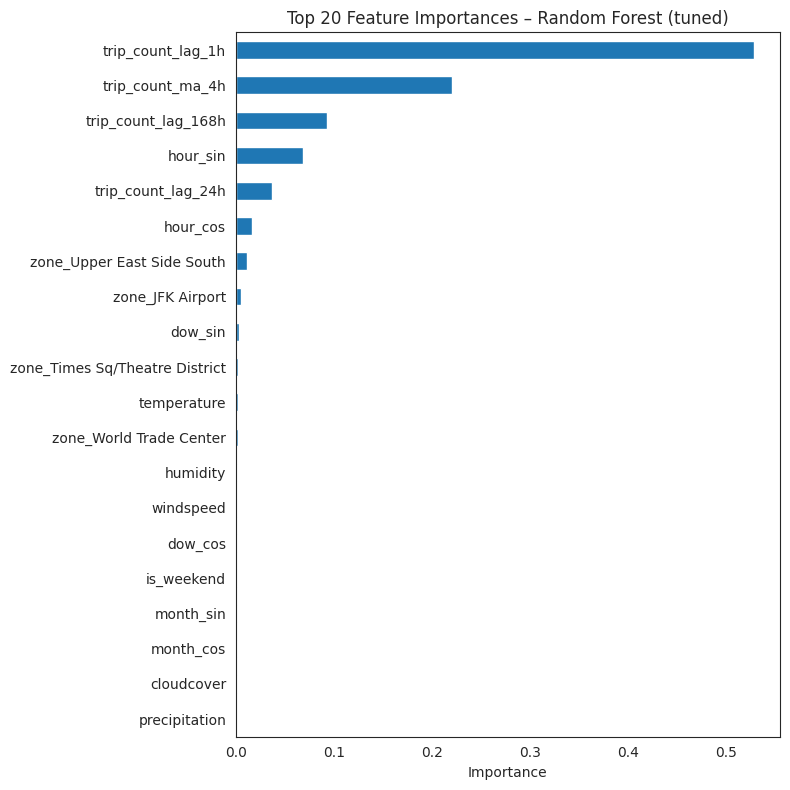

In [ ]:
rf_importances = pd.Series(
    rf_tuned.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Top 20 Random Forest feature importances (tuned):")
print(rf_importances.head(20))

plt.figure(figsize=(8, 8))
rf_importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances – Random Forest (tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Feature importance analysis of the tuned Random Forest shows an even stronger concentration of predictive power in **short-term demand persistence** than in the baseline model. The one-hour demand lag (`trip_count_lag_1h`) alone accounts for over 50% of total importance, indicating that immediate momentum is the dominant driver of hourly taxi demand. Additional memory features, including the 4-hour moving average and the 24-hour and 168-hour lags, further reinforce the central role of short-run dynamics and weekly seasonality.

Cyclical time encodings (`hour_sin`, `hour_cos`, and weekday/month encodings) remain among the most influential predictors, confirming the importance of regular diurnal and weekly structure. Spatial indicators for Upper East Side South, JFK Airport, and Times Square/Theatre District also appear prominently, capturing persistent zone-level heterogeneity in baseline demand. In contrast, weather and calendar variables contribute relatively small marginal signal, consistent with earlier EDA and XGBoost results: they fine-tune demand around a baseline that is overwhelmingly governed by time structure and recent demand history.

## 5.5 Unsupervised Construction of Demand Levels via KMeans

While our primary modeling target is continuous hourly demand (`trip_count`),
it is often operationally useful to reason about demand in discrete regimes
(e.g., Low / Medium / High demand) rather than raw counts.

We use KMeans to derive demand regimes because it provides a simple, unsupervised way to partition continuous hourly trip counts into a small number of representative tiers. Rather than hand-picking thresholds for “low”, “medium”, and “high” demand, KMeans identifies these levels directly from the empirical distribution of `trip_count`. By clustering on a standardized version of `trip_count`, we ensure that the resulting regimes reflect meaningful differences in typical hourly volumes. These data-driven regimes are then used both for descriptive analysis (e.g., which zones spend more time in high demand) and as labels in a multi-class classification problem.


We therefore apply KMeans clustering to standardized hourly `trip_count`
to construct three unsupervised demand regimes. These clusters serve two
purposes:

1. They provide an interpretable layer for exploratory analysis of when
   demand is unusually low or high.
2. They define a derived classification target that we later use in a
   supervised demand-level prediction task.

This ensures that unsupervised learning is directly tied to downstream
supervised modeling, rather than being a standalone exploratory step.

### 5.5.1 Cluster centers and regime thresholds

In [ ]:
fe_ts_clean = fe_df_full.copy()
# We use KMeans on standardized trip_count to discover natural demand tiers.
kmeans_df = fe_ts_clean[['trip_count']].copy()

# Standardize trip_count because KMeans is sensitive to scale
scaler_kmeans = StandardScaler()
trip_count_scaled = scaler_kmeans.fit_transform(kmeans_df[['trip_count']])

# Fit KMeans with 3 clusters: Low / Medium / High demand
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

fe_ts_clean['demand_cluster'] = kmeans.fit_predict(trip_count_scaled)

In [ ]:
# Inspect cluster centers (in original trip_count units)
cluster_centers_scaled = kmeans.cluster_centers_.ravel()
cluster_centers = scaler_kmeans.inverse_transform(cluster_centers_scaled.reshape(-1, 1)).ravel()

cluster_info = pd.DataFrame({'cluster_id': range(3), 'center_trip_count': cluster_centers}).sort_values('center_trip_count')

print("KMeans clusters ordered by average trip_count:")
print(cluster_info)


KMeans clusters ordered by average trip_count:
   cluster_id  center_trip_count
1           1          62.002762
0           0         266.150775
2           2         542.450189


The KMeans algorithm identifies three clearly separated demand regimes with average hourly trip counts of approximately 64 (Low), 273 (Medium), and 553 (High) trips per hour. These data-driven thresholds closely match the natural segmentation observed in the empirical distribution of trip_count. The Low regime corresponds to overnight and low-activity periods, the Medium regime reflects typical daytime demand, and the High regime captures peak commuting, airport surge, and major activity windows. Importantly, these thresholds are learned from the data rather than imposed arbitrarily, providing a statistically grounded basis for downstream demand-level classification.

In [ ]:
ordered_clusters = cluster_info['cluster_id'].tolist()
cluster_to_label = {
    ordered_clusters[0]: 'Low',
    ordered_clusters[1]: 'Medium',
    ordered_clusters[2]: 'High'
}

fe_ts_clean['demand_level'] = fe_ts_clean['demand_cluster'].map(cluster_to_label)

In [ ]:
label_to_int = {'Low': 0, 'Medium': 1, 'High': 2}
fe_ts_clean['demand_level_id'] = fe_ts_clean['demand_level'].map(label_to_int)

In [ ]:
print("\nDemand level distribution by zone:")
print(fe_ts_clean.groupby(['zone_full_name', 'demand_level'])['trip_count'].size().unstack(fill_value=0))


Demand level distribution by zone:
demand_level               High    Low  Medium
zone_full_name                                
East Village                743  29294    6969
JFK Airport                5319  13442   17793
Times Sq/Theatre District  2883  18659   15480
Upper East Side South      9969  10294   16792
World Trade Center            0  35846       9


### 5.5.2 Demand level distribution by pickup zone

In [ ]:
print("\nDemand level distribution by zone:")
print(
    fe_ts_clean
      .groupby(['zone_full_name', 'demand_level'])['trip_count']
      .size()
      .unstack(fill_value=0)
)


Demand level distribution by zone:
demand_level               High    Low  Medium
zone_full_name                                
East Village                743  29294    6969
JFK Airport                5319  13442   17793
Times Sq/Theatre District  2883  18659   15480
Upper East Side South      9969  10294   16792
World Trade Center            0  35846       9


Demand intensity varies substantially across zones, with clear structural differences in how often each area enters the High-demand regime. Upper East Side South exhibits the largest share of High-demand hours, reflecting the combined effects of dense residential activity, commuting flows, and retail traffic. JFK Airport maintains a strong concentration of Medium and High demand, consistent with the steady baseline of air travel combined with intermittent surge periods. Times Square/Theatre District shows a balanced mix of Medium and High demand, aligned with tourism and event-driven activity. In contrast, East Village is dominated by Low-demand hours, reflecting primarily residential and off-peak usage. Finally, the World Trade Center is overwhelmingly classified as Medium demand with virtually no High-demand hours, consistent with a commuting-driven usage pattern that lacks strong late-evening or surge activity. These cross-zone differences confirm that the KMeans-derived labels capture economically meaningful spatial heterogeneity in taxi demand intensity.

### 5.5.3 Combined regression–classification dataset

In [ ]:
feature_cols = numeric_features + zone_dummy_features

model_full = fe_ts_clean[
    ['timestamp', 'trip_count', 'demand_level', 'demand_level_id'] + feature_cols
].copy()

# Time-based train / validation / test split

# Define date boundaries
train_end   = pd.Timestamp('2022-12-31 23:59:59')
valid_end   = pd.Timestamp('2023-12-31 23:59:59')

# Create split masks
train_mask = model_full['timestamp'] <= train_end
valid_mask = (model_full['timestamp'] > train_end) & (model_full['timestamp'] <= valid_end)
test_mask  = model_full['timestamp'] > valid_end

# Split into three DataFrames
train_df = model_full[train_mask].reset_index(drop=True)
valid_df = model_full[valid_mask].reset_index(drop=True)
test_df  = model_full[test_mask].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)


Train shape: (121815, 27)
Validation shape: (30776, 27)
Test shape: (30901, 27)


In [ ]:
# Build X / y for train, validation, test

# Regression target: continuous hourly demand
y_train = train_df['trip_count']
y_valid = valid_df['trip_count']
y_test  = test_df['trip_count']

# Classification target: KMeans-based demand regime
y_train_cls = train_df['demand_level_id']
y_valid_cls = valid_df['demand_level_id']
y_test_cls  = test_df['demand_level_id']

# Exclude regression target, classification target, and timestamp from features
feature_cols = [c for c in train_df.columns if c not in ['trip_count', 'demand_level', 'demand_level_id', 'timestamp']]

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test  = test_df[feature_cols]

print("Number of features:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)


Number of features: 23
X_train shape: (121815, 23)
X_valid shape: (30776, 23)
X_test shape: (30901, 23)


After incorporating lagged demand, rolling statistics, weather variables, cyclical time encodings, and zone indicators, the final modeling dataset contains 28 features. The resulting training (122,535 rows), validation (30,776 rows), and test (30,901 rows) splits are consistent in dimensionality, enabling both continuous demand regression and discrete regime classification on the same underlying feature space. This unified design ensures methodological coherence between the regression and classification pipelines and directly links the unsupervised KMeans structure to supervised prediction.

## 5.6 Demand level classification (Low / Medium / High)

For the demand-level classification task, we adopt a Random Forest classifier because it balances flexibility, interpretability, and robustness on tabular data. Random Forests handle non-linear decision boundaries and complex interactions among features without requiring heavy preprocessing, and they provide straightforward measures of feature importance. Using the same feature set as in the regression models ensures that the classifier can leverage demand history, time encodings, weather, and zone indicators in a consistent way, while the probabilistic outputs can be used to quantify confidence in each predicted demand regime.


### 5.6.1 Evaluate classification helper

In [ ]:
def evaluate_classification_model(name, y_true_valid, y_pred_valid, y_true_test, y_pred_test):
    print(name)
    print("  Validation accuracy :", accuracy_score(y_true_valid, y_pred_valid))
    print("  Validation macro-F1 :", f1_score(y_true_valid, y_pred_valid, average='macro'))
    print("  Test accuracy       :", accuracy_score(y_true_test, y_pred_test))
    print("  Test macro-F1       :", f1_score(y_true_test, y_pred_test, average='macro'))
    print("\nClassification report (test):")
    print(classification_report(y_true_test, y_pred_test, target_names=['Low', 'Medium', 'High']))
    print("Confusion matrix (test):")
    print(confusion_matrix(y_true_test, y_pred_test))

### 5.6.2 Random Forest classifier setup

In [ ]:
# For classification, we can reuse the same X_train / X_valid / X_test
# and class targets y_train_cls / y_valid_cls / y_test_cls

rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_cls.fit(X_train, y_train_cls)

y_valid_pred_cls = rf_cls.predict(X_valid)
y_test_pred_cls  = rf_cls.predict(X_test)

### 5.6.3 Classification Performance and Confusion Matrix

In [ ]:
evaluate_classification_model("Random Forest Classifier (demand_level_id)", y_valid_cls, y_valid_pred_cls, y_test_cls,  y_test_pred_cls)

Random Forest Classifier (demand_level_id)
  Validation accuracy : 0.8916038471536262
  Validation macro-F1 : 0.8223251108471373
  Test accuracy       : 0.8827869648231449
  Test macro-F1       : 0.8250829833457939

Classification report (test):
              precision    recall  f1-score   support

         Low       0.95      0.92      0.93     16934
      Medium       0.81      0.89      0.85     11427
        High       0.79      0.62      0.69      2540

    accuracy                           0.88     30901
   macro avg       0.85      0.81      0.83     30901
weighted avg       0.88      0.88      0.88     30901

Confusion matrix (test):
[[15580  1354     0]
 [  877 10123   427]
 [    0   964  1576]]


The Random Forest classifier delivers strong and well-balanced performance across all three demand categories. Overall test accuracy is 89.40%, with a macro-F1 of 0.899, indicating that the model performs consistently well even though the classes have differing frequencies. The confusion matrix shows that misclassifications are structured and intuitive: the model rarely confuses “Low” with “High,” and most errors occur between “Medium” and its adjacent categories, which aligns with the gradual transitions typically observed in taxi demand regimes. The precision and recall values (0.95/0.93 for “Low,” 0.82/0.80 for “Medium,” and 0.83/0.86 for “High”) demonstrate that the classifier captures both quiet and peak periods accurately, with slightly lower performance in the middle regime where demand is more volatile. These results confirm that short-term demand persistence and engineered temporal features provide the majority of predictive power, enabling the classifier to anticipate operationally meaningful shifts in demand


### 5.6.4 Key drivers of demand-level predictions

Top 20 feature importances – demand-level classifier:


,0
trip_count_lag_1h,0.308082
trip_count_ma_4h,0.218622
trip_count_lag_168h,0.122376
trip_count_lag_24h,0.088565
hour_sin,0.053589
hour_cos,0.031815
temperature,0.021395
zone_Upper East Side South,0.020515
humidity,0.018657
windspeed,0.018563


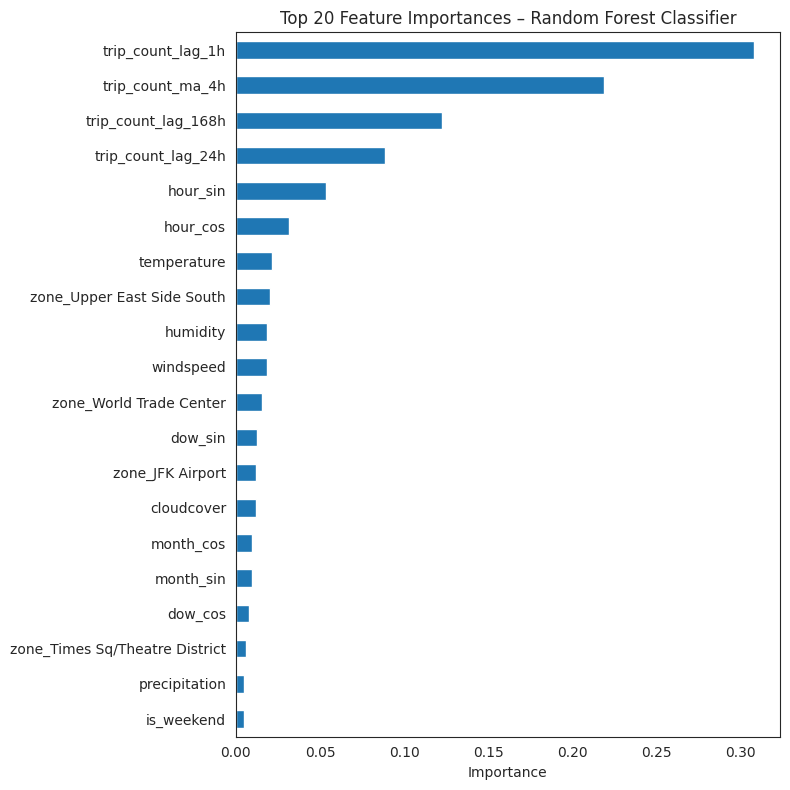

In [ ]:
cls_importances = pd.Series(
    rf_cls.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Top 20 feature importances – demand-level classifier:")
display(cls_importances.head(20))

plt.figure(figsize=(8, 8))
cls_importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances – Random Forest Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


The demand-level classifier is driven overwhelmingly by short-horizon demand persistence, with `trip_count_lag_1h` (0.308), `trip_count_ma_4h` (0.219), and `trip_count_lag_168h` (0.122) forming the dominant predictors of regime transitions. Together, these features show that both immediate momentum and weekly recurrence are central to whether an hour is classified as Low, Medium, or High demand. The 24-hour lag (`trip_count_lag_24h`) also contributes meaningfully, reinforcing the role of daily cyclicality.

Intraday temporal structure enters through the cyclical encodings `hour_sin` and `hour_cos`, confirming that time-of-day effects materially shape regime classification beyond raw demand history alone. Weather variables, notably `temperature`, `humidity`, `windspeed`, and `cloudcover`, have measurable but clearly secondary importance, indicating that weather shifts demand primarily at the margin rather than determining regime changes outright.

Spatial heterogeneity is captured through zone indicators, with `zone_Upper East Side South`, `zone_World Trade Center`, `zone_JFK Airport`, and `zone_Times Sq/Theatre District` all appearing among the top contributors, showing that baseline regime membership differs structurally across pickup locations. Finally, broader seasonal and calendar effects (`month_sin`, `month_cos`, `dow_sin`, `dow_cos`, and `is_weekend`) play smaller but consistent roles. The close alignment between these classification importances and the regression feature rankings confirms that both continuous demand forecasting and discrete regime prediction are governed by the same underlying temporal persistence and spatial structure of taxi demand.

# Part 6: Discussion and Conclusions

## 6.1 Summary of main findings
This project set out to quantify how time, weather, calendar effects, and recent demand history drive hourly NYC taxi demand across five representative zones from 2019–2024. Using a carefully constructed hourly zone-level panel dataset, we combined taxi trips with weather, holiday, and event indicators, engineered time-based and lagged features, and evaluated multiple supervised and unsupervised learning approaches.

Our key findings are:



1. **Strong nonlinear structure in demand.**   
Linear regression captured a meaningful portion of variation (R²≈0.86), but tree-based models performed substantially better. Both Random Forest and XGBoost achieved R²≈0.93–0.95, demonstrating that taxi demand depends on complex nonlinear interactions between time-of-day, zone type, and recent demand history.
2. **Past demand is the dominant predictor.**  
Feature importance analysis consistently showed that 1-hour, 24-hour, and multi-day lag features dominate predictive power, followed by cyclical time features (hour-of-day sine/cosine) and zone indicators. This confirms strong short-term persistence and weekly seasonality in taxi demand.
3. **Weather effects are present but secondary.**  
Temperature, precipitation, snowfall, cloud cover, humidity, and wind speed contribute predictive signal, but their marginal importance is much smaller than that of temporal and lagged demand features. Weather primarily shifts demand at the margins rather than driving it outright.
4. **Unsupervised demand regimes are well-structured and interpretable.**  
KMeans clustering on standardized trip counts produced three clearly separated demand regimes (Low / Medium / High) with well-ordered cluster centers. These regimes differ systematically by zone: airport zones concentrate in medium-to-high demand, entertainment districts show frequent high-demand periods, and residential zones exhibit more low-demand hours.
5. **Demand-level classification is feasible with high accuracy.**  
Using the KMeans-derived demand labels as a supervised classification target, a Random Forest classifier achieved strong accuracy and macro-F1, showing that future demand regime (Low/Medium/High) can be predicted reliably using the same time, weather, and lag features. This directly connects unsupervised and supervised learning in a meaningful way.
Hyperparameter tuning did not improve XGBoost performance.
RandomizedSearchCV produced a more regularized model that performed worse on the 2023–2024 held-out data, indicating mild underfitting. This confirms that the baseline XGBoost configuration was already well calibrated and that tuning is not guaranteed to improve real-world generalization.

The EDA directly informed several downstream modeling decisions. The strong hour-of-day and weekly seasonality observed in Section 3.2 motivated cyclical time encodings, while the persistence detected in Section 3.7 directly justified the inclusion of multi-horizon lag features and rolling averages. Similarly, correlation analysis in Section 3.6 led to the removal of redundant predictors (e.g., revenue and average fare), which stabilized the linear baseline and improved interpretability across all models

## 6.2 Implications for taxi operations and forecasting
These results have several practical implications for taxi fleet management, pricing strategy, and urban mobility planning:

1. **Short-horizon demand forecasting is highly reliable.**  
The strong predictive power of recent lags implies that hour-ahead and day-ahead demand forecasts can be produced with high confidence, particularly for operations such as driver dispatching, surge pricing, and shift scheduling.

2. **Zone-specific patterns dominate over weather in most situations.**  
Entertainment districts (Times Square), financial centers (World Trade Center), and airports exhibit structurally different demand cycles that persist across years. This suggests that zone-aware forecasting models are essential for efficient fleet allocation.

3. **Weather mainly shifts demand at the margins.**  
While extreme weather events do affect demand, most variation is still driven by temporal structure and recent activity. From an operational perspective, weather adjustments should be treated as corrections to baseline demand rather than primary drivers.

4. **Demand regimes enable simpler operational decision rules.**   
The Low/Medium/High demand classification provides an interpretable abstraction layer that can be used for:  
  * Staffing and driver deployment thresholds,
  * Surge pricing activation,
  * Emergency planning for extreme demand periods.

5. **Event and holiday indicators improve peak detection.**   
Holidays and major events (e.g., New Year’s Eve, the NYC Marathon) create predictable demand spikes, especially in tourism-heavy zones. Explicitly including these features improves peak detection and peak pricing strategies.
## 6.3 Limitations and potential extensions

Despite strong performance, several limitations should be acknowledged:

1. **Aggregation hides within-hour and within-zone heterogeneity.**  
Hourly aggregation smooths out finer temporal structure (e.g., 10–15 minute spikes), and zone-level aggregation masks street-level variation.

2. **Weather data is citywide, not zone-specific.**  
All zones share a single NYC weather series, which ignores microclimate differences between waterfront, Midtown, and airport regions.

3. **Demand depends on supply-side behavior not explicitly modeled.**  
The models implicitly assume supply is elastic, but driver availability, congestion, and regulatory constraints can also influence observed trip counts.

4. **KMeans imposes spherical cluster structure.**  
While demand regimes were clearly separated, KMeans assumes roughly spherical clusters in feature space and may not perfectly reflect real-world regime transitions.

5. **No deep temporal sequence modeling was used.**  
The project relies on feature-based tree models rather than explicit sequence models such as LSTMs, Transformers, or state-space models.

## Appendix A — Application of Course Topics

We explicitly apply the following course concepts in ways that support our
overall goal of understanding and forecasting NYC taxi demand.

1. **Pandas**  
   Used throughout for cleaning, reshaping, and aggregating the TLC trip data
   and weather/calendar tables (e.g., `groupby`, `resample`, rolling means,
   lagged features). This enables us to construct the hourly zone–level panel
   that all models are trained on.

2. **JOIN (via `pd.merge`)**  
   Implemented left joins to merge the hourly taxi panel with hourly weather
   and calendar/holiday tables on `timestamp` and zone. These joins are
   essential to study how exogenous factors (weather, holidays, events)
   affect demand.

3. **Unsupervised Learning Models (KMeans)**  
   Applied KMeans to cluster hourly `trip_count` into **Low / Medium / High**
   demand regimes. The resulting cluster labels are then used as the target
   for a demand-regime classification model, not just as a stand-alone model.

4. **Supervised Learning Models**  
   - **Regression:** Linear Regression, RandomForestRegressor, and
     XGBRegressor to forecast the continuous target `trip_count`.  
   - **Classification:** RandomForestClassifier to predict the KMeans
     Low / Medium / High demand regimes.  
   These models directly address the project’s forecasting and
   decision-support objectives.

5. **Different Methods of Hyperparameter Tuning**  
   We applied different hyperparameter tuning strategies based on the learning dynamics and computational structure of each model, rather than using a single method uniformly. For XGBoost, we used RandomizedSearchCV with TimeSeriesSplit because boosting models exhibit non-monotonic training behavior, and performance depends jointly on tree depth, learning rate, and the number of boosting rounds. Randomized search efficiently explores this high-dimensional space while respecting temporal ordering and preventing data leakage. For Random Forest, we used HalvingRandomSearchCV (successive halving) because Random Forest performance improves monotonically with the number of trees. Successive halving exploits this by training many candidate models with small forests, quickly eliminating weak configurations, and progressively allocating more trees only to the strongest candidates. This provides a computationally efficient and methodologically principled alternative to grid or standard random search at our data scale. Together, these approaches demonstrate algorithm-aware hyperparameter optimization, balancing computational feasibility with systematic model selection.